# 11. Pressures III: Nicknames, Missing Fields, and the Circular Teacher

**The question.** Can supervision teach *nuance* without teaching *mistakes*? Three
training-time interventions promise a targeted improvement, and each has a failure mode
that lives on the other side of the same dial. (1) **TRN-06**: feeding the encoder
lexicon-generated nickname pairs (bill = william) should raise nickname-slice recall —
but the same "different given name, same person" pressure is exactly what must NOT
generalize to twins, Jr/Sr pairs, and birth-year confusables, where a different given
name (or suffix, or year) is the *only* thing separating two real people. (2) The
**TRN-05 missing-field factor**: does a visible `[MISSING]` token beat silently dropping
empty fields once the eval stream is actually missing-heavy — the regime notebook 08's
nearly-complete corpus could not probe? (3) **LABEL-PROV**: every deployed ER system
eventually trains on its own (or a predecessor's) output — Fellegi–Sunter links, an
administrative key like NCID (lit_review §8; the NB03 audit measured exactly how dirty
that key is). What does a student measurably lose when its teacher's labels replace the
truth, and *where* does the loss land?

**What this notebook settles.** A 2-arm TRN-06 slice {no nickname supervision, +lexicon
pairs} scored on BOTH sides at once — nickname-slice recall AND the must-not-merge
slices (twin/household, Jr–Sr, birth-year) plus *planted* household confusables from the
calibrated corpus's own ops log; the TRN-05 missing-field factor {token, drop} at the
notebook-08 winning scheme, re-evaluated on a field-dropout-boosted eval slice; and a
live circular-teacher demonstration — student A trained on true `entity_id` pairs vs
student B trained on a documented FS-style teacher's predicted clusters, both judged on
truth, the gap sliced by where the teacher was right vs wrong.

**Scope honesty, up front.** Everything trained here is the smoke-tier scratch
char/byte encoder (pretrained-subword arms are `# [RUN-IN-TARGET mac]` —
huggingface.co is blocked from this container, `notes/COMPAT.md`). Single-seed rows are
DEMONSTRATIONS of machinery read through notebook 09's MET-04 detectability bar; the
definitive multi-seed matrices are tier=mid/node and every verdict below says so. No
entity appears on both sides of any train/eval boundary (entity-disjoint `met07_splits`,
PLAN §5), and that rail actively shapes the LABEL-PROV design below — the registered
`bas01_scored_pairs` teacher covers only the *eval* half, so training labels come from
an in-notebook stand-in teacher, loudly documented where it happens.

In [1]:
import copy
import hashlib
import time

import jellyfish
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import roc_auc_score

from er_lab.blocking import ann, matchkeys
from er_lab.cluster.schemes import transitive_closure
from er_lab.config import REPO_ROOT, config_hash, load_config_from_env, set_all_seeds
from er_lab.data.schema import ROLES
from er_lab.eval.bootstrap import bootstrap_ci, paired_delta
from er_lab.eval.metrics import pairwise
from er_lab.eval.operating_points import find_threshold_for_precision
from er_lab.infra.artifacts import ArtifactRegistry
from er_lab.infra.device import describe_platform
from er_lab.models.encoders import build_encoder
from er_lab.noise.channels import field_dropout, load_lexicon, nickname
from er_lab.probes.battery import build_probe_set
from er_lab.probes.geometry import alignment, hubness, rankme, uniformity
from er_lab.reporting import figures
from er_lab.reporting.cards import conjecture_card, verdict_box
from er_lab.serialize import serialize_frame, serialize_record
from er_lab.train.loop import train_encoder
from er_lab.train.mining import build_pairs_inbatch

cfg = load_config_from_env()
registry = ArtifactRegistry.from_env()
figures.setup_style()
set_all_seeds(cfg.run.seed)
NB_T0 = time.time()
SECTION_TIMES: list[tuple[str, float]] = []


def tick(label: str, t0: float) -> None:
    """Record and print one section's wall-clock — the smoke budget is measured, not vibes."""
    secs = time.time() - t0
    SECTION_TIMES.append((label, secs))
    print(f"[section timing] {label}: {secs:.0f}s")

In [2]:
# Tier banner — where and under what config this run happened.
print(f"tier        = {cfg.run.tier}")
print(f"config hash = {config_hash(cfg)}")
for key, val in describe_platform().items():
    print(f"  {key:>14}: {val}")

tier        = smoke
config hash = 129c9d9243ca
              os: Linux-6.18.44-fc-v22-x86_64-with-glibc2.39
          python: 3.11.15
           torch: 2.13.0+cu130
  cuda_available: False
   mps_available: False
       cpu_count: 4
          ram_gb: 15.7


## Tier constants — and the two rules every arm obeys

**Rule 1 — budget-matching is step-count accounting** (PLAN §3.1): every compared arm
runs the *exact same number of optimizer steps*, asserted from the returned training
history. **Rule 2 — one judging recipe**: every trained encoder in this notebook is
scored by the same shared system-metric helper (§1), so comparisons are about arms,
never about recipes. The dials below scale sizes with tier; the protocol
(precision-0.99 operating point, entity-unit BCa CIs, entity-disjoint splits) is
identical at every tier. Four budget-matched encoders train at smoke; the whole
notebook targets **<= ~30 min on the 4-CPU container** (measured per section, printed
at the end).

In [3]:
TIER = str(cfg.run.tier)
STEPS_BY_TIER = {"smoke": 250, "mid": 2000, "target": 4000, "analytical": 250}
SIZES = {"smoke": 3_000, "mid": None, "target": None, "analytical": 3_000}  # train records
EVAL_N = {"smoke": 4_000, "mid": None, "target": None, "analytical": 4_000}  # eval records
GRID = {"smoke": 40, "mid": 150, "target": 200, "analytical": 40}[TIER]
N_BOOT = {"smoke": 400, "mid": 1000, "target": 2000, "analytical": 400}[TIER]
PROBE_N = {"smoke": 120, "mid": 400, "target": 800, "analytical": 120}[TIER]
TRUE_PAIR_N = {"smoke": 300, "mid": 1000, "target": 2000, "analytical": 300}[TIER]
GEO_N = {"smoke": 1_500, "mid": 4_000, "target": 8_000, "analytical": 1_500}[TIER]
HH_PAIR_N = {"smoke": 300, "mid": 1000, "target": 2000, "analytical": 300}[TIER]
MODEL_SHAPE = {
    "smoke": {"dim": 128, "layers": 2, "heads": 4, "max_len": 128},
    "mid": {"dim": 256, "layers": 4, "heads": 4, "max_len": 192},
    "target": {"dim": 384, "layers": 6, "heads": 6, "max_len": 192},
    "analytical": {"dim": 128, "layers": 2, "heads": 4, "max_len": 128},
}[TIER]
STEPS = STEPS_BY_TIER[TIER]
PREC_TARGET = 0.99  # PLAN §5 primary fixed entity-precision operating point
CAND_K = 10  # eval candidate budget: ann.candidates(k=10, index='flat')
ENC_BATCH = 256  # inference encode batch
PRIMARY_SEED = int(cfg.run.seed)
# TRN-05 missing-stress eval: which fields get dropped, how hard (documented params)
DROP_FIELDS = ("dob", "city", "zip", "sex", "occupation")
DROP_RATE, DROP_PASSES = 0.6, 2

# Budget-matched encoder + step budget, set through the typed cfg keys so the config hash
# on every registered artifact records exactly what trained.
cfg.model.kind = "scratch_char"
cfg.model.dim = MODEL_SHAPE["dim"]
cfg.model.layers = MODEL_SHAPE["layers"]
cfg.model.heads = MODEL_SHAPE["heads"]
cfg.model.max_len = MODEL_SHAPE["max_len"]
cfg.train.steps = STEPS
BATCH = int(cfg.train.batch_size)
print(f"tier={TIER}: steps={STEPS} batch={BATCH} model=(dim {cfg.model.dim}, "
      f"layers {cfg.model.layers}, heads {cfg.model.heads}, max_len {cfg.model.max_len}); "
      f"train-slice budget {SIZES[TIER]}, eval-slice budget {EVAL_N[TIER]}, grid={GRID}, "
      f"n_boot={N_BOOT}; smoke budget <= ~30 min")

tier=smoke: steps=250 batch=64 model=(dim 128, layers 2, heads 4, max_len 128); train-slice budget 3000, eval-slice budget 4000, grid=40, n_boot=400; smoke budget <= ~30 min


### The MET-04 lens, inherited

Notebook 09's closing instruction: notebooks 10–11 quote the registered MET-04
single-seed detectability bar rather than inventing their own. The bar is
`2*sqrt(2)*sd_replicate` — a one-replicate-per-arm B³F1 delta smaller than this is
indistinguishable from seed + noise-draw randomness, and every system-metric verdict
below reads its margins through it. The load is exists-gated (this notebook's DAG
contract requires only `calibrated_corpus` + `met07_splits`); if notebook 09 has not
registered the table at this tier the fallback is the MET-04 *card's* predicted
variance floor, loudly labeled provisional.

In [4]:
if registry.exists("met04_power_table", tier=cfg.run.tier):
    met04_tbl, met04_meta = registry.load("met04_power_table", tier=cfg.run.tier)
    SD_REPLICATE = float(met04_meta["extra"]["sd_replicate"])
    DETECT_BAR = float(met04_meta["extra"]["detect_bar_single_seed"])
    # both registered bars travel: the cards' pre-registered 2*sqrt(2)*sd_replicate bar
    # scores each verdict; the residual-inclusive bar is the primary honest noise lens
    # (residual run-level noise does not cancel between independently trained arms)
    DETECT_BAR_RESID = float(
        met04_meta["extra"].get("detect_bar_residual_inclusive", DETECT_BAR)
    )
    _pw = met04_tbl[met04_tbl["kind"] == "power"]
    SEEDS_NEEDED = {float(r["delta"]): int(r["seeds_needed"]) for _, r in _pw.iterrows()}
    BAR_SOURCE = (f"met04_power_table run {met04_meta['created_at']} "
                  f"(cfg {met04_meta['config_hash']}, scope {met04_meta['extra']['scope'][:11]})")
else:
    SD_REPLICATE = 0.01  # the MET-04 card's pre-registered variance floor
    DETECT_BAR = float(2.0 * np.sqrt(2.0) * SD_REPLICATE)
    DETECT_BAR_RESID = DETECT_BAR  # provisional: no measured residual component exists yet
    SEEDS_NEEDED = {}
    BAR_SOURCE = ("PROVISIONAL — met04_power_table is not registered at this tier "
                  "(notebook 09 not yet run here); using the MET-04 card's predicted "
                  "variance floor sd=0.01 until the measured table exists")
    print("!! " + BAR_SOURCE)
print(f"MET-04 lens: sd_replicate={SD_REPLICATE:.4f} -> single-seed bars: "
      f"pre-registered 2*sqrt(2)*sd = {DETECT_BAR:.4f}, residual-inclusive "
      f"{DETECT_BAR_RESID:.4f} (primary honest lens)   [{BAR_SOURCE}]")

MET-04 lens: sd_replicate=0.0305 -> single-seed bars: pre-registered 2*sqrt(2)*sd = 0.0862, residual-inclusive 0.0865 (primary honest lens)   [met04_power_table run 2026-08-29T15:51:14.080789+00:00 (cfg 98af614e2bcd, scope SMOKE PILOT)]


## 1. The arena, and the one recipe every encoder is judged by

Both inputs load through the registry at this run's tier: the calibrated corpus
(notebook 05) and the MET-07 splits. Training uses the **entity-disjoint train half**,
subsampled *entity-complete* (whole clusters, never split); evaluation uses a fixed
entity-complete subsample of the **eval half**, shared by every arm (paired
comparisons).

**The shared system-metric recipe** (used verbatim for every trained encoder below):
serialize the eval slice *per the arm's own serialization config* (the TRN-05 factor
makes serialization part of the arm, exactly as notebook 08's protocol states) →
encode → `ann.candidates(k=10, index='flat')` → cosine scores mapped to [0, 1] →
`find_threshold_for_precision` at the locked 0.99 entity-precision point (PLAN §5
**loud fallback**, never a silent protocol switch) → transitive closure → B-cubed with
**entity-unit BCa CIs**. The helper also hands back the chosen clustering and the
threshold, because TRN-06's false-merge proxies are *at-threshold* readings — each
arm's confusables are judged at that arm's own operating point.

In [5]:
t_sec = time.time()
corpus, corpus_meta = registry.load("calibrated_corpus", tier=cfg.run.tier)
splits, splits_meta = registry.load("met07_splits", tier=cfg.run.tier)
CORPUS_PROVENANCE = (
    f"calibrated_corpus run {corpus_meta['created_at']} (cfg {corpus_meta['config_hash']}, "
    f"tier {corpus_meta['tier']}, seed {corpus_meta['extra']['seed']})"
)
print(f"corpus: {CORPUS_PROVENANCE}")
print(f"  {len(corpus):,} records / {corpus['entity_id'].nunique():,} entities")

SCHEME = "entity_disjoint"
train_ids = set(splits["schemes"][SCHEME]["train"])
eval_ids = set(splits["schemes"][SCHEME]["eval"])
train_full = corpus[corpus["record_id"].isin(train_ids)].reset_index(drop=True)
eval_full = corpus[corpus["record_id"].isin(eval_ids)].reset_index(drop=True)
straddle = splits["metadata"]["checks"][SCHEME]["entities_straddling"]
print(f"split scheme: {SCHEME} (seed {splits['metadata']['seed']}, "
      f"entities straddling the boundary: {straddle})")
assert straddle == 0, "entity-disjoint split must have zero straddling entities (PLAN §5)"


def entity_complete_subsample(
    frame: pd.DataFrame, n_records: int | None, rng: np.random.Generator
) -> pd.DataFrame:
    """Random whole entities until ~n_records — an entity is never split across the cut.

    (Same helper as notebooks 05/09; still notebook-local — a shared home in
    er_lab.data would serve, carried as a package-gap note.)
    """
    if n_records is None or n_records >= len(frame):
        return frame.reset_index(drop=True)
    ents = frame["entity_id"].unique()
    sizes = frame["entity_id"].value_counts()
    picked: list[str] = []
    total = 0
    for i in rng.permutation(len(ents)):
        picked.append(ents[i])
        total += int(sizes[ents[i]])
        if total >= n_records:
            break
    return frame[frame["entity_id"].isin(set(picked))].reset_index(drop=True)


train_slice = entity_complete_subsample(
    train_full, SIZES[TIER], np.random.default_rng(PRIMARY_SEED)
)
ev_slice = entity_complete_subsample(
    eval_full, EVAL_N[TIER], np.random.default_rng(PRIMARY_SEED + 1)
)
print(f"train slice: {len(train_slice):,} records / "
      f"{train_slice['entity_id'].nunique():,} entities")
print(f"eval  slice: {len(ev_slice):,} records / {ev_slice['entity_id'].nunique():,} "
      "entities — fixed across ALL arms (paired)")

corpus: calibrated_corpus run 2026-08-29T15:42:13.364770+00:00 (cfg 129c9d9243ca, tier smoke, seed 17)
  32,259 records / 2,507 entities
split scheme: entity_disjoint (seed 17, entities straddling the boundary: 0)
train slice: 3,010 records / 222 entities
eval  slice: 4,026 records / 300 entities — fixed across ALL arms (paired)


In [6]:
# Serialization + the shared recipe. TEXT_ROLES is notebook 08's explicit list,
# inherited — full_name EXCLUDED per NB08's measured decision (it doubles serialized
# bytes into certain truncation at max_len=128, and the noise channels leave it STALE,
# leaking the clean name back through a side channel). Frames handed to the training
# loop are trimmed to the same set below; per-arm scheme/missing because serialization
# IS a factor in this notebook.
TEXT_ROLES = ["given_name", "family_name", "dob", "city", "zip", "sex"]
EXCLUDED_ROLES = [c for c in corpus.columns if c in ROLES and c not in TEXT_ROLES]
SER_SCHEME, SER_MISSING = str(cfg.serialize.scheme), str(cfg.serialize.missing)


def texts_of(frame: pd.DataFrame, scheme: str | None = None,
             missing: str | None = None) -> list[str]:
    return serialize_frame(
        frame, text_roles=TEXT_ROLES,
        scheme=scheme or SER_SCHEME, missing=missing or SER_MISSING,
    ).tolist()


EVAL_TEXTS = texts_of(ev_slice)
TRUTH_EV = ev_slice.set_index("record_id")["entity_id"]
lens = np.array([len(t.encode("utf-8")) for t in EVAL_TEXTS])
share_trunc = float((lens > cfg.model.max_len - 1).mean())
print(f"serialization default: scheme={SER_SCHEME} missing={SER_MISSING}, "
      f"roles={TEXT_ROLES}")
print(f"  role columns excluded from serialization (NB08's measured decision, see above): "
      f"{EXCLUDED_ROLES}")
print(f"eval text length: median {int(np.median(lens))} bytes; {share_trunc:.0%} exceed "
      f"max_len={cfg.model.max_len} and are TRUNCATED — the notebook-08-measured smoke "
      "constraint, carried into every battery reading below (mid-tier window covers "
      "the full row).")


def fresh_encoder(seed: int, model_cfg=None):
    """Deterministic encoder init: same seed => identical starting weights."""
    set_all_seeds(seed)
    return build_encoder(model_cfg if model_cfg is not None else cfg)


def param_hash(module) -> str:
    """12-hex digest of all parameters in state_dict order — init-identity checks (NB08)."""
    h = hashlib.sha256()
    for tensor in module.state_dict().values():
        h.update(tensor.detach().cpu().numpy().tobytes())
    return h.hexdigest()[:12]


def train_arm(corpus_df, *, seed, arm_cfg=None, encoder=None):
    """One budget-matched run (infonce / in-batch / no augmentation) with its cfg.

    The loss/miner/augment factors are FIXED at the lab defaults this whole notebook:
    the pressures under test here are the *pair supply* (TRN-06: which positives exist;
    LABEL-PROV: who labeled them) and the *serialization* (TRN-05 factor via arm_cfg) —
    everything else identical. Asserts the step budget from the returned history.
    Returns (encoder, history, secs, init_hash): the pre-training param hash makes the
    'identical init' claim checkable, not assumed (NB08's rail). The frame is trimmed
    to TEXT_ROLES-bearing columns so the loop serializes the same field set as eval.
    """
    corpus_df = corpus_df.drop(
        columns=[c for c in corpus_df.columns if c in ROLES and c not in TEXT_ROLES]
    )
    use_cfg = arm_cfg if arm_cfg is not None else cfg
    enc = fresh_encoder(seed, use_cfg) if encoder is None else encoder
    init_hash = param_hash(enc)
    t0 = time.time()
    enc, hist = train_encoder(
        enc, corpus_df, use_cfg, loss_name="infonce", miner_name="inbatch",
        augment_kind="none", steps=STEPS, seed=seed,
    )
    secs = time.time() - t0
    assert len(hist) == STEPS and int(hist["step"].iloc[-1]) == STEPS, (
        f"budget violation: expected exactly {STEPS} optimizer steps, "
        f"history shows {len(hist)}"
    )
    return enc, hist, secs, init_hash


def system_metric(encoder, *, label, frame=None, texts=None, with_ci=True) -> dict:
    """THE shared recipe (module docstring above): every encoder answers the same question.

    frame/texts default to the standard eval slice; the TRN-05 factor passes the
    dropout-boosted frame with per-arm serialization. Returns the matrix row plus
    (non-registered) 'pred' clustering and 'emb' for downstream at-threshold probes.
    """
    frame = ev_slice if frame is None else frame
    texts = EVAL_TEXTS if texts is None else texts
    truth = frame.set_index("record_id")["entity_id"]
    records = pd.Index(truth.index)
    pos = {rid: i for i, rid in enumerate(frame["record_id"].astype(str))}
    t0 = time.time()
    emb = encoder.encode(texts, batch_size=ENC_BATCH)
    cand = ann.candidates(frame, emb, k=CAND_K, index="flat")
    ia = cand["a"].astype(str).map(pos).to_numpy()
    ib = cand["b"].astype(str).map(pos).to_numpy()
    cos = np.einsum("ij,ij->i", emb[ia], emb[ib])
    scored = pd.DataFrame({"a": cand["a"], "b": cand["b"],
                           "prob": np.clip((cos + 1.0) / 2.0, 0.0, 1.0)})
    cache: dict[float, pd.Series] = {}

    def clusterer(t: float) -> pd.Series:
        if t not in cache:
            cache[t] = transitive_closure(scored, threshold=float(t), records=records)
        return cache[t]

    res = find_threshold_for_precision(
        scored.rename(columns={"prob": "score"}), clusterer, truth,
        target=PREC_TARGET, grid=GRID,
    )
    if not res["attained"]:
        print(f"  !! [{label}] precision {PREC_TARGET} UNATTAINABLE on this eval slice — "
              f"reporting the highest-attainable point P={res['attained_precision']:.4f} "
              f"(fallback='{res['fallback']}'; PLAN §5 rail: loud, never silent)")
    pred = clusterer(res["threshold"])
    row = {
        "threshold": res["threshold"], "attained": bool(res["attained"]),
        "attained_precision": res["attained_precision"], "recall_at": res["recall_at"],
        "f1": res["f1_at"], "n_candidate_pairs": len(scored),
        "pred": pred, "emb": emb,
    }
    if with_ci:
        ci = bootstrap_ci(pred, truth, "bcubed_f1", unit="entity", n_boot=N_BOOT,
                          seed=PRIMARY_SEED)
        row["f1_lo"], row["f1_hi"] = ci["ci_low"], ci["ci_high"]
    row["eval_secs"] = time.time() - t0
    return row


tick("§1 arena + shared recipe", t_sec)

serialization default: scheme=colval missing=token, roles=['given_name', 'family_name', 'dob', 'city', 'zip', 'sex']
  role columns excluded from serialization (NB08's measured decision, see above): ['full_name']
eval text length: median 162 bytes; 100% exceed max_len=128 and are TRUNCATED — the notebook-08-measured smoke constraint, carried into every battery reading below (mid-tier window covers the full row).
[section timing] §1 arena + shared recipe: 0s


### The property instruments: battery slices, planted confusables, and a full-name gap

One probe set (the notebook-08 battery vocabulary) and one geometry panel are built
ONCE on the eval slice and measured under each TRN-06 encoder — same probes, same
true-pair reference, so property deltas between arms are about the arms. Two additions
this notebook needs beyond the standard battery:

1. **Per-pair cosines.** `battery_report` returns per-slice *summaries*; TRN-06's
   headline reading is *at-threshold* — what fraction of nickname pairs would actually
   LINK, and what fraction of confusable pairs would actually MERGE, at each arm's own
   0.99-precision operating point. A small helper recomputes slice cosines pair-by-pair
   (a `battery_report(return_pairs=True)` option would serve — package-gap note).
2. **The full-name staleness gap, and planted confusables.** The nickname channel swaps
   `given_name` but leaves `full_name` stale (documented NB05 behavior). Under NB08's
   inherited serialization `full_name` never reaches the encoder at all (§1), so the
   stale clean name can no longer leak through the text — the standard `nickname_swap`
   slice and the `nickname_fullsync` slice (full_name synced before serialization)
   should now read alike. Both are kept: the fullsync slice is the one the TRN-06 card
   names, and their agreement is itself a check that the leakage channel is closed.
   On the must-not side, the sharpest instrument is not synthetic at all: the calibrated
   corpus *planted* 649 household confusables (twin/sibling records haunting a real
   entity, `calibrated_corpus_ops` log), and the eval half carries their pairings with
   the entities they haunt — real must-not-merge pairs with fully consistent fields.

3. **A role-admitting probe serializer (NB08's design, adopted).** `historical_50k`
   declares no `name_suffix` role, but the battery's `suffix_jr_sr` slice *injects*
   one — so the probe serializer must admit the injected role and honor the probe's
   own field order (exactly NB08's `PROBE_ROLE_SET` serializer, under which both the
   suffix and field-order slices were live by deliberate design). With the fixed-role
   serializer this notebook first used, the suffix slice was silently empty and the
   card's Jr–Sr guard structurally unmeasurable — a serializer choice, not a corpus
   fact. Adopted here: `suffix_jr_sr` (and `field_order_permutation`) are live
   eval-time probes, measured under each arm.

In [7]:
t_sec = time.time()
try:
    _lex_raw = load_lexicon(str(REPO_ROOT / "data"))
    LEXICON = {
        c: {v for v in vs if v not in ("has_nickname", "relationship")}
        for c, vs in _lex_raw.items() if c != "name1"
    }
    LEXICON = {c: v for c, v in LEXICON.items() if v} or None
    lex_note = f"carltonnorthern lexicon, sanitized (NB04 workaround): {len(LEXICON or {})} names"
except FileNotFoundError:
    LEXICON = None
    lex_note = "lexicon file absent -> nickname channel built-in mini-lexicon"
print(lex_note + " — English-centric with documented provenance bias (PLAN §4); every "
      "TRN-06 claim below carries that limitation")
NICK_CHANNEL = nickname(LEXICON)


PROBE_ROLE_SET = set(TEXT_ROLES) | {"name_suffix"}


def probe_serialize(row: dict) -> str:
    """NB08's role-admitting probe serializer, honoring the probe's own field order.

    Keeps the field-order slice live (serialize_record itself is order-fixed by
    text_roles) and admits the battery's injected name_suffix role, so the
    suffix_jr_sr guard is measurable on this corpus.
    """
    roles = [k for k in row if k in PROBE_ROLE_SET]
    return serialize_record(row, text_roles=roles, scheme=SER_SCHEME, missing=SER_MISSING)


PROBES = build_probe_set(
    ev_slice, serialize=probe_serialize, seed=PRIMARY_SEED, lexicon=LEXICON,
    n_per_slice=PROBE_N,
)


def sync_full_name(frame: pd.DataFrame, ops: pd.DataFrame) -> pd.DataFrame:
    """Propagate a given-name swap into full_name (first-occurrence replace, else
    recompose) — the NB05 name-change convention, applied where the nickname channel
    leaves full_name stale."""
    out = frame.copy()
    swaps = ops[ops["field"] == "given_name"].set_index("record_id")
    for rid, op in swaps.iterrows():
        mask = out["record_id"].astype(str) == str(rid)
        if not mask.any():
            continue
        i = out.index[mask][0]
        full = out.at[i, "full_name"]
        before, after = str(op["before"]), str(op["after"])
        if pd.notna(full) and before in str(full):
            out.at[i, "full_name"] = str(full).replace(before, after, 1)
        else:
            fam = out.at[i, "family_name"]
            out.at[i, "full_name"] = f"{after} {fam}" if pd.notna(fam) else after
    return out


# the sharper nickname slice: given-name swapped AND full_name synced
_rng_nick = np.random.default_rng(PRIMARY_SEED + 3)
_nick_base = ev_slice[ev_slice["given_name"].notna()]
_nick_base = _nick_base.iloc[
    np.sort(_rng_nick.choice(len(_nick_base), size=min(PROBE_N * 3, len(_nick_base)),
                             replace=False))
]
_swapped, _nick_ops = NICK_CHANNEL.apply(_nick_base, _rng_nick, 1.0)
_swapped = sync_full_name(_swapped, _nick_ops)
_changed = set(_nick_ops["record_id"].astype(str))
fullsync_rows = [
    ("nickname_fullsync", "should_hold",
     probe_serialize({k: r0[k] for k in r0.index if k not in ("record_id", "entity_id",
                                                              "source")}),
     probe_serialize({k: r1[k] for k in r1.index if k not in ("record_id", "entity_id",
                                                              "source")}))
    for (_, r0), (_, r1) in zip(_nick_base.iterrows(), _swapped.iterrows())
    if str(r0["record_id"]) in _changed
][:PROBE_N]
PROBES = pd.concat(
    [PROBES, pd.DataFrame(fullsync_rows, columns=["slice", "kind", "text_a", "text_b"])],
    ignore_index=True,
)
lex_cover = len(_changed) / max(len(_nick_base), 1)
print(f"probe slices built (+ nickname_fullsync, {len(fullsync_rows)} pairs; lexicon "
      f"covers {lex_cover:.0%} of sampled eval given-names):")
display(PROBES.groupby(["kind", "slice"]).size().rename("n_pairs").to_frame())

# true-pair reference + geometry sample (NB09 conventions)
_tp = build_pairs_inbatch(ev_slice, n_pairs=TRUE_PAIR_N, seed=PRIMARY_SEED)
_etext = pd.Series(EVAL_TEXTS, index=ev_slice["record_id"].astype(str))
TRUE_PAIRS_TXT = pd.DataFrame({
    "text_a": _etext.loc[_tp["a_id"]].to_numpy(),
    "text_b": _etext.loc[_tp["b_id"]].to_numpy(),
})
_rng_geo = np.random.default_rng(PRIMARY_SEED + 7)
_geo_pos = np.sort(_rng_geo.choice(len(ev_slice), size=min(GEO_N, len(ev_slice)),
                                   replace=False))
GEO_TEXTS = [EVAL_TEXTS[i] for i in _geo_pos]
_rid_geo = ev_slice["record_id"].astype(str).iloc[_geo_pos]
GEO_KIND = np.where(
    _rid_geo.str.contains("#dup"), "generated_duplicate",
    np.where(_rid_geo.str.contains("#hh1"), "household_confusable", "base_record"),
)

carltonnorthern lexicon, sanitized (NB04 workaround): 1232 names — English-centric with documented provenance bias (PLAN §4); every TRN-06 claim below carries that limitation


probe slices built (+ nickname_fullsync, 120 pairs; lexicon covers 69% of sampled eval given-names):


n_pairs
kind          slice                           
must_not_hold different_birth_year          84
              suffix_jr_sr                 120
              twin_household               120
should_hold   field_order_permutation      120
              format_drift                  85
              nickname_fullsync            120
              nickname_swap                 82
              typo@0.02                    120
              typo@0.05                    119
              typo@0.1                     120
              typo@0.2                     120

In [8]:
# Planted household confusables: every #hh1 record in the EVAL HALF paired with records
# of the base entity it haunts (household_id), twin/sibling kind from the ops log.
if registry.exists("calibrated_corpus_ops", tier=cfg.run.tier):
    ops_log, _ops_meta = registry.load("calibrated_corpus_ops", tier=cfg.run.tier)
    HH_KIND = (ops_log[ops_log["field"] == "__kind__"]
               .set_index("record_id")["after"].astype(str).to_dict())
    hh_kind_note = f"ops log loaded ({len(HH_KIND)} confusable kinds)"
else:
    HH_KIND = {}
    hh_kind_note = ("!! calibrated_corpus_ops absent at this tier — twin/sibling "
                    "breakdown unavailable, kinds recorded as 'unknown'")
print(hh_kind_note)

_rng_hh = np.random.default_rng(PRIMARY_SEED + 11)
hh_recs = eval_full[eval_full["record_id"].astype(str).str.contains("#hh1")]
by_entity = {k: g for k, g in eval_full.groupby("entity_id", sort=True)}
hh_pairs: list[dict] = []
for _, r in hh_recs.iterrows():
    base = by_entity.get(r["household_id"])
    if base is None or not len(base):
        continue
    take = base.iloc[_rng_hh.permutation(len(base))[:2]]
    for _, b in take.iterrows():
        hh_pairs.append({
            "confusable_id": str(r["record_id"]), "base_id": str(b["record_id"]),
            "kind": HH_KIND.get(str(r["entity_id"]), "unknown"),
            "text_conf": probe_serialize({k: r[k] for k in r.index
                                          if k not in ("record_id", "entity_id",
                                                       "source", "household_id")}),
            "text_base": probe_serialize({k: b[k] for k in b.index
                                          if k not in ("record_id", "entity_id",
                                                       "source", "household_id")}),
        })
HH_PAIRS = pd.DataFrame(hh_pairs)
if len(HH_PAIRS) > HH_PAIR_N:
    HH_PAIRS = HH_PAIRS.iloc[
        np.sort(_rng_hh.choice(len(HH_PAIRS), size=HH_PAIR_N, replace=False))
    ].reset_index(drop=True)
print(f"planted must-not-merge pairs from the eval half: {len(HH_PAIRS)} "
      f"({HH_PAIRS['kind'].value_counts().to_dict()}) — a confusable is a DIFFERENT "
      "person planted in a real household; linking one of these pairs is a false merge "
      "by construction")


def pair_cosines(encoder, text_a: pd.Series, text_b: pd.Series) -> np.ndarray:
    """Cosines for aligned text pairs, encoding each unique text once."""
    uniq = sorted(set(text_a) | set(text_b))
    emb = encoder.encode(uniq, batch_size=ENC_BATCH)
    pos = {t: i for i, t in enumerate(uniq)}
    ia = text_a.map(pos).to_numpy(dtype=int)
    ib = text_b.map(pos).to_numpy(dtype=int)
    return np.einsum("ij,ij->i", emb[ia], emb[ib])


def slice_panel(encoder) -> tuple[pd.DataFrame, dict[str, np.ndarray]]:
    """Battery-style per-slice summary + raw per-pair cosines (for at-threshold rates)."""
    cos_all = pair_cosines(encoder, PROBES["text_a"], PROBES["text_b"])
    true_cos = pair_cosines(encoder, TRUE_PAIRS_TXT["text_a"], TRUE_PAIRS_TXT["text_b"])
    rows, raw = [], {"__true__": true_cos}
    for name, grp in PROBES.groupby("slice", sort=False):
        sims = cos_all[grp.index.to_numpy()]
        raw[str(name)] = sims
        kind = str(grp["kind"].iloc[0])
        auc = float("nan")
        if kind == "must_not_hold" and len(sims):
            labels = np.concatenate([np.ones(len(true_cos)), np.zeros(len(sims))])
            auc = float(roc_auc_score(labels, np.concatenate([true_cos, sims])))
        rows.append({"slice": str(name), "kind": kind, "n": len(sims),
                     "mean_cos": float(np.mean(sims)), "auc_vs_true": auc})
    return pd.DataFrame(rows).set_index("slice"), raw


def geometry_panel(encoder) -> tuple[dict, np.ndarray]:
    emb_a = encoder.encode(TRUE_PAIRS_TXT["text_a"].tolist(), batch_size=ENC_BATCH)
    emb_b = encoder.encode(TRUE_PAIRS_TXT["text_b"].tolist(), batch_size=ENC_BATCH)
    geo_emb = encoder.encode(GEO_TEXTS, batch_size=ENC_BATCH)
    geo = {
        "align": alignment(emb_a, emb_b),
        "uniform": uniformity(geo_emb),
        "rankme": rankme(geo_emb),
        "hub_skew": hubness(geo_emb, k=10)["skewness"],
    }
    return geo, geo_emb


def pca2(emb: np.ndarray) -> np.ndarray:
    x = np.asarray(emb, dtype=np.float64)
    x = x - x.mean(axis=0)
    _u, _s, vt = np.linalg.svd(x, full_matrices=False)
    return x @ vt[:2].T


def link_rate(cos: np.ndarray, prob_threshold: float) -> float:
    """Share of pairs at/above an arm's operating point (cos space <-> prob space)."""
    return float(np.mean(cos >= 2.0 * prob_threshold - 1.0))


def paired_rate_delta(cos_a, thr_a, cos_b, thr_b, *, seed, n_boot=None):
    """Pair-resample bootstrap CI for link_rate(A) - link_rate(B) on SHARED probe pairs.

    Pair-unit resampling, percentile interval — a diagnostic instrument for synthetic
    probe slices (which have no entity structure), deliberately weaker than the
    entity-unit BCa machinery that guards the system metric.
    """
    n_boot = N_BOOT if n_boot is None else n_boot
    cos_a, cos_b = np.asarray(cos_a), np.asarray(cos_b)
    assert len(cos_a) == len(cos_b), "paired delta needs the same probe pairs"
    rng = np.random.default_rng(seed)
    point = link_rate(cos_a, thr_a) - link_rate(cos_b, thr_b)
    boots = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, len(cos_a), size=len(cos_a))
        boots[i] = link_rate(cos_a[idx], thr_a) - link_rate(cos_b[idx], thr_b)
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return {"delta": point, "lo": float(lo), "hi": float(hi)}


tick("§1b property instruments", t_sec)

ops log loaded (649 confusable kinds)


planted must-not-merge pairs from the eval half: 300 ({'twin': 177, 'sibling': 123}) — a confusable is a DIFFERENT person planted in a real household; linking one of these pairs is a false merge by construction
[section timing] §1b property instruments: 22s


## 2. Three conjectures, before any encoder exists

All three cards render (and register, immutably) *now* — before a single training step
or teacher score — per PLAN §5. Each card pre-registers its decision rule, including
the honest "it's noise" outcome via the MET-04 bar quoted above. And the PLAN §5
distinction is in force throughout: the *adoption gate* (property moved AND metric
moved, CIs excluding zero) is necessary evidence and **not** mediation; nothing below
reports two marginal effects as a mediation claim — at one smoke seed, mediation is
UNEXPLAINED by design, and the verdict boxes say so.

In [9]:
_ = conjecture_card(
    card_id="TRN-06",
    conjecture=(
        "Lexicon-pair nickname supervision teaches the nuance without the mistake: "
        "swapping a documented fraction of training positives for lexicon-generated "
        "nickname pairs makes the encoder nickname-invariant where it should be, "
        "WITHOUT transferring 'different given name, same person' to the confusable "
        "slices where a small name difference is the only thing separating two real "
        "people (twins/households, Jr vs Sr, adjacent birth years)."
    ),
    pressure=(
        "nickname supervision {off, lexicon pairs} with everything else locked: same "
        "corpus slice, same entities, infonce / in-batch / no augmentation, colval "
        "serialization, identical scratch-char encoder init, identical optimizer-step "
        "count (asserted from history). The lexicon arm rewrites ONE record per "
        "eligible multi-record training entity to a lexicon variant of its given name "
        "(full_name synced, NB05 convention) so a measured, documented fraction of the "
        "training-pair pool becomes nickname positives; the pretrained-subword regime "
        "completes the locked 2x2 at mid/target (PLAN section 3.1: 2 cells x regime)"
    ),
    property=(
        "should-hold side: nickname-slice mean cosine and at-threshold link rate "
        "(standard battery nickname_swap slice + the sharper full_name-synced slice). "
        "must-not-hold side: twin_household / suffix_jr_sr / different_birth_year "
        "battery AUC-vs-true and at-threshold false-link rates, plus mean cosine and "
        "at-threshold merge rate on PLANTED household confusable pairs from the "
        "calibrated corpus's ops log (real twin/sibling records vs the entities they "
        "haunt, evaluated at each arm's own precision-0.99 operating point)"
    ),
    metric=(
        "B-cubed F1 with entity-unit BCa 95% CI on the entity-disjoint eval slice at "
        "the precision-0.99 operating point (loud highest-attainable fallback, PLAN "
        "section 5), one shared recipe for both arms; paired entity-bootstrap delta on "
        "shared eval draws"
    ),
    prediction=(
        "P1 (the gain): the lexicon arm raises the nickname-slice at-threshold link "
        "rate, pair-bootstrap 95% CI excluding zero, on the full_name-synced slice at "
        "minimum. P2 (the guard): no must-not-hold damage — the planted-confusable "
        "merge rate and the three confusable false-link rates do not rise with CI "
        "excluding zero, and confusable AUCs do not drop by more than 0.05. P3 "
        "(system): B-cubed F1 does not degrade beyond the MET-04 single-seed bar. "
        "Decision rule, pre-registered: CONFIRMED requires P1 AND P2 (with P3 not "
        "violated); a P1 gain accompanied by P2 damage REFUTES (that is the "
        "teaching-mistakes outcome, and finding it is the point); anything short of "
        "P1's CI is UNEXPLAINED at one seed. English-lexicon provenance bias is a "
        "standing limitation on any confirmation. Mediation (supervision -> nickname "
        "invariance -> F1) is not claimable from one seed and is not claimed."
    ),
    registry=registry,
)

### Conjecture card `TRN-06`

| | |
|---|---|
| **Conjecture** | Lexicon-pair nickname supervision teaches the nuance without the mistake: swapping a documented fraction of training positives for lexicon-generated nickname pairs makes the encoder nickname-invariant where it should be, WITHOUT transferring 'different given name, same person' to the confusable slices where a small name difference is the only thing separating two real people (twins/households, Jr vs Sr, adjacent birth years). |
| **Pressure (dial)** | nickname supervision {off, lexicon pairs} with everything else locked: same corpus slice, same entities, infonce / in-batch / no augmentation, colval serialization, identical scratch-char encoder init, identical optimizer-step count (asserted from history). The lexicon arm rewrites ONE record per eligible multi-record training entity to a lexicon variant of its given name (full_name synced, NB05 convention) so a measured, documented fraction of the training-pair pool becomes nickname positives; the pretrained-subword regime completes the locked 2x2 at mid/target (PLAN section 3.1: 2 cells x regime) |
| **Embedding property** | should-hold side: nickname-slice mean cosine and at-threshold link rate (standard battery nickname_swap slice + the sharper full_name-synced slice). must-not-hold side: twin_household / suffix_jr_sr / different_birth_year battery AUC-vs-true and at-threshold false-link rates, plus mean cosine and at-threshold merge rate on PLANTED household confusable pairs from the calibrated corpus's ops log (real twin/sibling records vs the entities they haunt, evaluated at each arm's own precision-0.99 operating point) |
| **System metric** | B-cubed F1 with entity-unit BCa 95% CI on the entity-disjoint eval slice at the precision-0.99 operating point (loud highest-attainable fallback, PLAN section 5), one shared recipe for both arms; paired entity-bootstrap delta on shared eval draws |
| **Pre-registered prediction** | P1 (the gain): the lexicon arm raises the nickname-slice at-threshold link rate, pair-bootstrap 95% CI excluding zero, on the full_name-synced slice at minimum. P2 (the guard): no must-not-hold damage — the planted-confusable merge rate and the three confusable false-link rates do not rise with CI excluding zero, and confusable AUCs do not drop by more than 0.05. P3 (system): B-cubed F1 does not degrade beyond the MET-04 single-seed bar. Decision rule, pre-registered: CONFIRMED requires P1 AND P2 (with P3 not violated); a P1 gain accompanied by P2 damage REFUTES (that is the teaching-mistakes outcome, and finding it is the point); anything short of P1's CI is UNEXPLAINED at one seed. English-lexicon provenance bias is a standing limitation on any confirmation. Mediation (supervision -> nickname invariance -> F1) is not claimable from one seed and is not claimed. |

*Immutable — sha256 `77c7c974b624`; registered before the affected runs, never edited (PLAN §5).*


In [10]:
_ = conjecture_card(
    card_id="TRN-05-MISSING-STRESS",
    conjecture=(
        "Notebook 08's missing-field factor was scored on a nearly-complete corpus, "
        "where the {token, drop} treatments barely differ at eval time; under a "
        "missing-heavy eval stream the treatments separate, and the visible [MISSING] "
        "token holds up better than silently dropping fields, because token-serialized "
        "records keep field identity and string geometry stable as cells vanish."
    ),
    pressure=(
        "missing-field treatment {[MISSING] token, drop} at notebook 08's winning "
        "serialization scheme (loaded from trn05_serialization_matrix when registered "
        "at this tier, else colval with the ordering noted), 2 budget-matched runs "
        "(identical steps, init seed, corpus slice; the token cell is notebook-09-style "
        "reuse of this notebook's control arm when the winning scheme equals the "
        "control's config, stated in the matrix meta); evaluated on BOTH the standard "
        "eval slice AND a field-dropout-boosted variant of the same slice (documented "
        "channel: field_dropout over dob/city/zip/sex/occupation, 2 passes at rate "
        "0.6, truth unchanged)"
    ),
    property=(
        "serialized-text degradation under missingness (bytes lost, share of records "
        "with >=1 dropped-of-the-listed fields) and the arm's threshold stability "
        "between the two eval regimes"
    ),
    metric=(
        "B-cubed F1 with entity-unit BCa 95% CI at the precision-0.99 operating point "
        "(loud fallback) on each eval regime; paired entity-bootstrap token-minus-drop "
        "delta on the boosted regime; rows appended into trn06_nickname_matrix under "
        "factor='missing_field' (notebook 08's artifact is NOT re-registered)"
    ),
    prediction=(
        "P1: on the dropout-boosted eval, token beats drop with the paired "
        "entity-bootstrap delta excluding zero. P2 (interaction): the token-minus-drop "
        "gap is larger on the boosted eval than on the standard eval. Decision rule: "
        "P1's paired CI is the primary test, read alongside the MET-04 bar; a "
        "sign-stable drop-beats-token on the boosted eval REFUTES; single-seed "
        "margins inside both are UNEXPLAINED — the definitive answer is the "
        "multi-seed 8-cell factorial at mid (placard)."
    ),
    registry=registry,
)

### Conjecture card `TRN-05-MISSING-STRESS`

| | |
|---|---|
| **Conjecture** | Notebook 08's missing-field factor was scored on a nearly-complete corpus, where the {token, drop} treatments barely differ at eval time; under a missing-heavy eval stream the treatments separate, and the visible [MISSING] token holds up better than silently dropping fields, because token-serialized records keep field identity and string geometry stable as cells vanish. |
| **Pressure (dial)** | missing-field treatment {[MISSING] token, drop} at notebook 08's winning serialization scheme (loaded from trn05_serialization_matrix when registered at this tier, else colval with the ordering noted), 2 budget-matched runs (identical steps, init seed, corpus slice; the token cell is notebook-09-style reuse of this notebook's control arm when the winning scheme equals the control's config, stated in the matrix meta); evaluated on BOTH the standard eval slice AND a field-dropout-boosted variant of the same slice (documented channel: field_dropout over dob/city/zip/sex/occupation, 2 passes at rate 0.6, truth unchanged) |
| **Embedding property** | serialized-text degradation under missingness (bytes lost, share of records with >=1 dropped-of-the-listed fields) and the arm's threshold stability between the two eval regimes |
| **System metric** | B-cubed F1 with entity-unit BCa 95% CI at the precision-0.99 operating point (loud fallback) on each eval regime; paired entity-bootstrap token-minus-drop delta on the boosted regime; rows appended into trn06_nickname_matrix under factor='missing_field' (notebook 08's artifact is NOT re-registered) |
| **Pre-registered prediction** | P1: on the dropout-boosted eval, token beats drop with the paired entity-bootstrap delta excluding zero. P2 (interaction): the token-minus-drop gap is larger on the boosted eval than on the standard eval. Decision rule: P1's paired CI is the primary test, read alongside the MET-04 bar; a sign-stable drop-beats-token on the boosted eval REFUTES; single-seed margins inside both are UNEXPLAINED — the definitive answer is the multi-seed 8-cell factorial at mid (placard). |

*Immutable — sha256 `0b0d92bb2768`; registered before the affected runs, never edited (PLAN §5).*


In [11]:
_ = conjecture_card(
    card_id="LABEL-PROV",
    conjecture=(
        "Training on a teacher's predicted links instead of true labels costs real "
        "system quality, and the cost is not uniform: it concentrates exactly on the "
        "hard pairs the teacher itself gets wrong — the circularity trap of "
        "administrative-key and legacy-linker supervision (lit_review section 8; the "
        "NB03 NCID audit measured the real-world teacher's error floor)."
    ),
    pressure=(
        "label provenance {truth entity_id, teacher-predicted clusters} with everything "
        "else locked (same corpus slice, infonce / in-batch / none, same encoder init, "
        "identical step budget). The teacher is an NB06-style Fellegi-Sunter stand-in "
        "built in-notebook — mean Jaro-Winkler over given_name/family_name/city plus "
        "exact-match indicators on dob/zip over matchkey-blocked candidate pairs — "
        "because the registered bas01_scored_pairs teacher scores only the EVAL half "
        "and the entity-disjoint rail forbids training on it (checked live, stated "
        "loudly); the stand-in is validated against bas01's FS scores on shared eval "
        "pairs. Teacher operating point: its own precision-0.99 threshold (charitable "
        "truth-tuned setting, documented), labels = transitive closure at that "
        "threshold"
    ),
    property=(
        "pairwise precision/recall of the teacher's training labels vs truth (the "
        "injected label-noise dose), and per-stratum separation: each student's "
        "true-vs-false pair AUC on a documented eval pair sample (matchkey candidate "
        "pairs + planted household-confusable pairs + seeded random cross-entity "
        "pairs — the dedup-dense corpus makes blocked pairs almost all true, so the "
        "sample must carry its own false pairs), stratified by whether the teacher "
        "scores that pair correctly at its threshold"
    ),
    metric=(
        "B-cubed F1 with entity-unit BCa 95% CI at the precision-0.99 operating point "
        "on the entity-disjoint truth-labeled eval slice, both students, shared "
        "recipe; paired entity-bootstrap A-minus-B delta; registered as "
        "label_provenance_audit"
    ),
    prediction=(
        "P1: student A (truth labels) beats student B (teacher labels) on B-cubed F1, "
        "paired delta positive; read through the MET-04 bar at one seed. P2 (the "
        "concentration claim): the A-minus-B AUC gap is larger on the teacher-wrong "
        "stratum than on the teacher-right stratum (pair-bootstrap CI of the "
        "difference-of-gaps excluding zero). Decision rule: CONFIRMED needs P1 "
        "sign-stable AND P2; teacher-labels matching or beating truth (sign-stable "
        "B >= A) REFUTES; margins inside CIs are UNEXPLAINED at one seed. The "
        "real-NCID-teacher and multi-seed versions are the definitive test "
        "(node placard)."
    ),
    registry=registry,
)

### Conjecture card `LABEL-PROV`

| | |
|---|---|
| **Conjecture** | Training on a teacher's predicted links instead of true labels costs real system quality, and the cost is not uniform: it concentrates exactly on the hard pairs the teacher itself gets wrong — the circularity trap of administrative-key and legacy-linker supervision (lit_review section 8; the NB03 NCID audit measured the real-world teacher's error floor). |
| **Pressure (dial)** | label provenance {truth entity_id, teacher-predicted clusters} with everything else locked (same corpus slice, infonce / in-batch / none, same encoder init, identical step budget). The teacher is an NB06-style Fellegi-Sunter stand-in built in-notebook — mean Jaro-Winkler over given_name/family_name/city plus exact-match indicators on dob/zip over matchkey-blocked candidate pairs — because the registered bas01_scored_pairs teacher scores only the EVAL half and the entity-disjoint rail forbids training on it (checked live, stated loudly); the stand-in is validated against bas01's FS scores on shared eval pairs. Teacher operating point: its own precision-0.99 threshold (charitable truth-tuned setting, documented), labels = transitive closure at that threshold |
| **Embedding property** | pairwise precision/recall of the teacher's training labels vs truth (the injected label-noise dose), and per-stratum separation: each student's true-vs-false pair AUC on a documented eval pair sample (matchkey candidate pairs + planted household-confusable pairs + seeded random cross-entity pairs — the dedup-dense corpus makes blocked pairs almost all true, so the sample must carry its own false pairs), stratified by whether the teacher scores that pair correctly at its threshold |
| **System metric** | B-cubed F1 with entity-unit BCa 95% CI at the precision-0.99 operating point on the entity-disjoint truth-labeled eval slice, both students, shared recipe; paired entity-bootstrap A-minus-B delta; registered as label_provenance_audit |
| **Pre-registered prediction** | P1: student A (truth labels) beats student B (teacher labels) on B-cubed F1, paired delta positive; read through the MET-04 bar at one seed. P2 (the concentration claim): the A-minus-B AUC gap is larger on the teacher-wrong stratum than on the teacher-right stratum (pair-bootstrap CI of the difference-of-gaps excluding zero). Decision rule: CONFIRMED needs P1 sign-stable AND P2; teacher-labels matching or beating truth (sign-stable B >= A) REFUTES; margins inside CIs are UNEXPLAINED at one seed. The real-NCID-teacher and multi-seed versions are the definitive test (node placard). |

*Immutable — sha256 `1ed04ce96a97`; registered before the affected runs, never edited (PLAN §5).*


## 3. TRN-06 — nickname supervision, scored on both sides

### 3a. Building the supervision arm: swap pairs, not budget

The training loop draws its positives from the within-entity pair pool, so the
cleanest way to mix lexicon pairs into training *without touching the budget* is to
rewrite the corpus the pool is built from: for every eligible training entity (>= 2
records, given name covered by the lexicon), ONE record — preferentially a generated
`#dup` — gets its given name swapped to a lexicon variant, `full_name` synced (the
NB05 name-change convention; a stale full name would let the encoder match the pair
trivially and never learn the nickname). Record count, entity structure, pair-pool
size, and step budget are all IDENTICAL to the control arm; the two corpora differ
only in those swapped name cells. The *realized* supervision dose is then measured on
the loop's own pair pool (same builder, same `n_pairs`, same seed) — the documented
"fraction of training pairs swapped for lexicon pairs" is a measurement, not an
intention.

In [12]:
t_sec = time.time()
_sizes_tr = train_slice.groupby("entity_id")["record_id"].transform("size")
_elig = train_slice[_sizes_tr >= 2]
_pick = (_elig.assign(_isdup=_elig["record_id"].astype(str).str.contains("#dup"))
         .sort_values(["entity_id", "_isdup"], ascending=[True, False])
         .groupby("entity_id").head(1).drop(columns="_isdup"))
_rng_sup = np.random.default_rng(PRIMARY_SEED + 21)
_picked_swap, _sup_ops = NICK_CHANNEL.apply(_pick, _rng_sup, 1.0)
_picked_swap = sync_full_name(_picked_swap, _sup_ops)
SWAPPED_IDS = set(_sup_ops[_sup_ops["field"] == "given_name"]["record_id"].astype(str))
sup_slice = train_slice.copy()
_swap_rows = _picked_swap[_picked_swap["record_id"].astype(str).isin(SWAPPED_IDS)]
sup_slice = pd.concat(
    [sup_slice[~sup_slice["record_id"].astype(str).isin(SWAPPED_IDS)], _swap_rows]
).sort_index().reset_index(drop=True)
assert len(sup_slice) == len(train_slice), "supervision arm must not change record count"
assert (sup_slice["entity_id"].value_counts().sort_index()
        == train_slice["entity_id"].value_counts().sort_index()).all(), (
    "supervision arm must not change entity structure")

# realized dose, measured on the loop's own pool (same builder, same n_pairs, same seed)
_pool = build_pairs_inbatch(sup_slice, n_pairs=max(8 * BATCH, 256), seed=PRIMARY_SEED)
_touch = (_pool["a_id"].astype(str).isin(SWAPPED_IDS)
          | _pool["b_id"].astype(str).isin(SWAPPED_IDS))
SUP_PAIR_FRACTION = float(_touch.mean())
n_multi = int((train_slice["entity_id"].value_counts() >= 2).sum())
print(f"eligible multi-record entities: {n_multi}; lexicon-swappable and swapped: "
      f"{len(SWAPPED_IDS)} records ({len(SWAPPED_IDS) / max(n_multi, 1):.0%} of "
      "multi-record entities)")
print(f"REALIZED supervision dose: {SUP_PAIR_FRACTION:.1%} of the training pair pool "
      f"({int(_touch.sum())}/{len(_pool)} pairs) now touches a lexicon-swapped record — "
      "this measured fraction is the documented dose in the registered matrix meta")
_ex = _sup_ops[_sup_ops["field"] == "given_name"].head(3)
for _, r in _ex.iterrows():
    print(f"  example swap: {r['before']} -> {r['after']}  ({r['record_id']})")
tick("§3a supervision-arm corpus", t_sec)

eligible multi-record entities: 184; lexicon-swappable and swapped: 136 records (74% of multi-record entities)
REALIZED supervision dose: 4.1% of the training pair pool (21/512 pairs) now touches a lexicon-swapped record — this measured fraction is the documented dose in the registered matrix meta
  example swap: jean -> janet  (Q10432805-4#dup4)
  example swap: john -> nathan  (Q112411-1#dup2)
  example swap: henry -> hal  (Q1349901-5#dup8)
[section timing] §3a supervision-arm corpus: 0s


### 3b. Two budget-matched arms, fully instrumented

Each arm answers: the shared system metric (with its own 0.99-precision threshold),
the slice panel (per-pair cosines → at-threshold link/false-link rates + AUCs), the
geometry panel, and the planted-confusable readings *at that arm's own threshold*.
The control arm is also this notebook's reusable baseline: it doubles as LABEL-PROV's
student A and (when notebook 08's winning scheme is the config default) as the TRN-05
factor's token cell — identical configuration, stated at each reuse.

In [13]:
t_sec = time.time()
arm_state: dict[str, dict] = {}


def run_trn06_arm(arm: str, frame: pd.DataFrame) -> dict:
    """Train + fully instrument one TRN-06 arm; returns the matrix row."""
    enc_a, hist_a, secs, ihash = train_arm(frame, seed=PRIMARY_SEED)
    sysrow = system_metric(enc_a, label=f"trn06/{arm}")
    rep, raw = slice_panel(enc_a)
    geo, geo_emb = geometry_panel(enc_a)
    thr = float(sysrow["threshold"])
    hh_cos = pair_cosines(enc_a, HH_PAIRS["text_conf"], HH_PAIRS["text_base"])

    def sl(name, col):
        return float(rep.loc[name, col]) if name in rep.index else float("nan")

    def lr_of(name):
        sims = raw.get(name)
        return link_rate(sims, thr) if sims is not None and len(sims) else float("nan")

    row = {
        "factor": "nickname_supervision", "arm": arm,
        "scheme": SER_SCHEME, "missing": SER_MISSING, "eval_regime": "standard",
        "seed": PRIMARY_SEED, "steps": len(hist_a), "batch": BATCH,
        "train_secs": secs, "reuse_of": None, "init_hash": ihash,
        "first_train_loss": float(hist_a["loss"].iloc[0]),
        "final_train_loss": float(hist_a["loss"].tail(20).mean()),
        **{k: sysrow[k] for k in ("f1", "f1_lo", "f1_hi", "recall_at",
                                  "attained_precision", "attained", "threshold",
                                  "n_candidate_pairs")},
        **geo,
        "nick_mean_cos": sl("nickname_swap", "mean_cos"),
        "nick_link_rate": lr_of("nickname_swap"),
        "nickfs_mean_cos": sl("nickname_fullsync", "mean_cos"),
        "nickfs_link_rate": lr_of("nickname_fullsync"),
        "twin_auc": sl("twin_household", "auc_vs_true"),
        "twin_link_rate": lr_of("twin_household"),
        "jrsr_auc": sl("suffix_jr_sr", "auc_vs_true"),  # LIVE via the role-admitting serializer
        "jrsr_link_rate": lr_of("suffix_jr_sr"),
        "dob_auc": sl("different_birth_year", "auc_vs_true"),
        "dob_link_rate": lr_of("different_birth_year"),
        "hh_mean_cos": float(np.mean(hh_cos)),
        "hh_merge_rate": link_rate(hh_cos, thr),
        "n_hh_pairs": len(hh_cos),
    }
    for kind in ("twin", "sibling"):
        m = (HH_PAIRS["kind"] == kind).to_numpy()
        row[f"hh_{kind}_merge_rate"] = link_rate(hh_cos[m], thr) if m.any() else float("nan")
    arm_state[f"trn06/{arm}"] = {
        "encoder": enc_a, "history": hist_a, "raw_cos": raw, "hh_cos": hh_cos,
        "pred": sysrow["pred"], "emb": sysrow["emb"], "geo_emb": geo_emb, "row": row,
    }
    print(f"  [{arm}] B3F1={row['f1']:.4f} [{row['f1_lo']:.4f},{row['f1_hi']:.4f}] "
          f"(P {row['attained_precision']:.4f}, R {row['recall_at']:.4f}) | "
          f"nickname link {row['nick_link_rate']:.2f} (fullsync "
          f"{row['nickfs_link_rate']:.2f}) | planted merge {row['hh_merge_rate']:.2f} | "
          f"loss {row['first_train_loss']:.3f} -> {row['final_train_loss']:.3f} | "
          f"init {ihash} | train {secs:.0f}s")
    return row


trn06_rows: list[dict] = [run_trn06_arm("off", train_slice)]

  [off] B3F1=0.6074 [0.5821,0.6360] (P 0.9906, R 0.4379) | nickname link 0.13 (fullsync 0.10) | planted merge 0.00 | loss 4.698 -> 1.042 | init cef0494ec267 | train 35s


In [14]:
# (one training arm per cell — a heavy cell under container contention can brush the
# runner's per-cell timeout)
trn06_rows.append(run_trn06_arm("lexicon_pairs", sup_slice))
assert trn06_rows[0]["steps"] == trn06_rows[1]["steps"], "TRN-06 arms must share one budget"
# 'identical init' is ASSERTED from the recorded param hashes, not assumed (NB08's rail)
assert trn06_rows[0]["init_hash"] == trn06_rows[1]["init_hash"], (
    f"TRN-06 arms must share one initialization, got "
    f"{[(r['arm'], r['init_hash']) for r in trn06_rows]}"
)
print(f"\nbudget-matched: both arms ran exactly {trn06_rows[0]['steps']} optimizer steps "
      "(asserted from each returned history)")
print(f"init check PASSED: both arms share param hash {trn06_rows[0]['init_hash']} — "
      "identical init asserted, not assumed")
tick("§3b TRN-06 arms", t_sec)

  [lexicon_pairs] B3F1=0.5855 [0.5593,0.6157] (P 0.9981, R 0.4143) | nickname link 0.10 (fullsync 0.08) | planted merge 0.00 | loss 4.698 -> 1.026 | init cef0494ec267 | train 33s

budget-matched: both arms ran exactly 250 optimizer steps (asserted from each returned history)
init check PASSED: both arms share param hash cef0494ec267 — identical init asserted, not assumed
[section timing] §3b TRN-06 arms: 83s


In [15]:
# Paired system-metric delta on SHARED entity draws (PLAN §5) + both-sides property
# deltas with pair-bootstrap CIs — the raw material of the pre-registered decision rule.
t_sec = time.time()
off, lex = arm_state["trn06/off"], arm_state["trn06/lexicon_pairs"]
d_sys06 = paired_delta(lex["pred"], off["pred"], TRUTH_EV, "bcubed_f1",
                       unit="entity", n_boot=N_BOOT, seed=PRIMARY_SEED)
prop_deltas: dict[str, dict] = {}
empty_slices: list[str] = []
for name in ("nickname_swap", "nickname_fullsync", "twin_household", "suffix_jr_sr",
             "different_birth_year"):
    a_cos, b_cos = lex["raw_cos"].get(name), off["raw_cos"].get(name)
    if a_cos is None or b_cos is None or not len(a_cos) or not len(b_cos):
        empty_slices.append(name)  # empty-by-construction (see §1b) — information
        continue
    prop_deltas[name] = paired_rate_delta(
        a_cos, float(lex["row"]["threshold"]),
        b_cos, float(off["row"]["threshold"]),
        seed=PRIMARY_SEED + 31,
    )
if empty_slices:
    print(f"slices empty by construction on this corpus (see §1b note): {empty_slices}")
prop_deltas["planted_household"] = paired_rate_delta(
    lex["hh_cos"], float(lex["row"]["threshold"]),
    off["hh_cos"], float(off["row"]["threshold"]),
    seed=PRIMARY_SEED + 32,
)
print("at-threshold link-rate deltas, lexicon minus off (pair-bootstrap 95% CI):")
for name, d in prop_deltas.items():
    tag = "SHOULD rise" if name.startswith("nickname") else "must NOT rise"
    print(f"  {name:>22}: {d['delta']:+.3f} [{d['lo']:+.3f}, {d['hi']:+.3f}]  ({tag})")
print(f"system paired delta (lexicon - off) B3F1: {d_sys06['delta']:+.4f} "
      f"[{d_sys06['ci_low']:+.4f}, {d_sys06['ci_high']:+.4f}] "
      f"sign_stable={d_sys06['sign_stable']}; MET-04 bar {DETECT_BAR:.4f}")
tick("§3c TRN-06 paired deltas", t_sec)

at-threshold link-rate deltas, lexicon minus off (pair-bootstrap 95% CI):
           nickname_swap: -0.037 [-0.085, +0.000]  (SHOULD rise)
       nickname_fullsync: -0.017 [-0.042, +0.000]  (SHOULD rise)
          twin_household: -0.008 [-0.025, +0.000]  (must NOT rise)
            suffix_jr_sr: +0.000 [+0.000, +0.000]  (must NOT rise)
    different_birth_year: +0.000 [+0.000, +0.000]  (must NOT rise)
       planted_household: +0.000 [+0.000, +0.000]  (must NOT rise)
system paired delta (lexicon - off) B3F1: -0.0218 [-0.0367, -0.0149] sign_stable=True; MET-04 bar 0.0862
[section timing] §3c TRN-06 paired deltas: 0s


In [16]:
# [RUN-IN-TARGET mac] the OTHER encoder regime: TRN-06's locked factor set is
# supervision {off, lexicon} x {pretrained-subword, scratch-char}. huggingface.co is
# blocked from the smoke container (notes/COMPAT.md go/no-go tree), so the pretrained
# arms run where weights can load: on the mac/node, or here if paths.hf_local points at
# offline weights. Real code gated on availability, not a comment.
t_sec = time.time()
PRETRAINED_READY = cfg.paths.hf_local is not None or TIER in ("mid", "target")
if PRETRAINED_READY:
    cfg_pre = copy.deepcopy(cfg)
    cfg_pre.model.kind = "pretrained"
    for arm, frame in (("off", train_slice), ("lexicon_pairs", sup_slice)):
        set_all_seeds(PRIMARY_SEED)
        enc_pre = build_encoder(cfg_pre)  # raises with the COMPAT placard if weights absent
        enc_pre, hist_pre, secs_pre, ihash_pre = train_arm(frame, seed=PRIMARY_SEED,
                                                           encoder=enc_pre)
        sys_pre = system_metric(enc_pre, label=f"trn06-pre/{arm}")
        trn06_rows.append({
            "factor": "nickname_supervision", "arm": f"{arm}@pretrained",
            "scheme": SER_SCHEME, "missing": SER_MISSING, "eval_regime": "standard",
            "seed": PRIMARY_SEED, "steps": len(hist_pre), "batch": BATCH,
            "train_secs": secs_pre, "reuse_of": None, "init_hash": ihash_pre,
            "first_train_loss": float(hist_pre["loss"].iloc[0]),
            "final_train_loss": float(hist_pre["loss"].tail(20).mean()),
            **{k: sys_pre[k] for k in ("f1", "f1_lo", "f1_hi", "recall_at",
                                       "attained_precision", "attained", "threshold",
                                       "n_candidate_pairs")},
        })
else:
    scr_secs = sum(r["train_secs"] for r in trn06_rows)
    print("[RUN-IN-TARGET mac] pretrained-subword arms skipped here: no paths.hf_local "
          f"and tier={TIER} has no huggingface egress (notes/COMPAT.md). Rerun THESE "
          "cells at tier=mid on the mac (or set paths.hf_local) to fill the 2 pretrained "
          f"cells; the 2 scratch arms above cost {scr_secs:.0f}s at {STEPS} steps here, "
          "and the pretrained encoder is ~40x larger — budget accordingly.")
tick("§3d pretrained gate", t_sec)

[RUN-IN-TARGET mac] pretrained-subword arms skipped here: no paths.hf_local and tier=smoke has no huggingface egress (notes/COMPAT.md). Rerun THESE cells at tier=mid on the mac (or set paths.hf_local) to fill the 2 pretrained cells; the 2 scratch arms above cost 69s at 250 steps here, and the pretrained encoder is ~40x larger — budget accordingly.
[section timing] §3d pretrained gate: 0s


## 4. The TRN-05 missing-field factor, under real missingness

### 4a. Winning scheme in, dropout-boosted eval out

The factor set is inherited, not invented: notebook 08 owns the serialization matrix,
and this notebook only carries its **missing-field treatment** {`[MISSING]` token,
drop} into the regime where the treatment can matter. The winning-08 scheme loads
exists-gated from `trn05_serialization_matrix` (if notebook 08 has not run at this
tier, the arms fall back to colval and the ordering violation is stated in the matrix
meta rather than papered over). The stress eval is the SAME eval slice — same
records, same entities, same truth — pushed through a documented `field_dropout`
boost, so token-vs-drop comparisons stay paired at the entity level and regime-vs-
regime comparisons are about missingness alone. The calibrated corpus's own measured
dropout rate is ~1e-5 (NSE-01: drift-visible floor only), which is exactly why
notebook 08 could not see this factor move; the boost is openly synthetic stress,
labeled as such, never presented as measured prevalence.

In [17]:
t_sec = time.time()
if registry.exists("trn05_serialization_matrix", tier=cfg.run.tier):
    m08, m08_meta = registry.load("trn05_serialization_matrix", tier=cfg.run.tier)
    _tok = m08[m08["missing"] == "token"].sort_values("bcubed_f1", ascending=False)
    WIN_SCHEME = str(_tok["scheme"].iloc[0])
    ORDER_NOTE = (f"winning-08 scheme = {WIN_SCHEME} (trn05_serialization_matrix run "
                  f"{m08_meta['created_at']}, best token-arm B3F1 "
                  f"{float(_tok['bcubed_f1'].iloc[0]):.4f})")
    nb08_ref = {
        f"{r['scheme']}/{r['missing']}": float(r["bcubed_f1"])
        for _, r in m08.iterrows()
    }
else:
    WIN_SCHEME = "colval"
    ORDER_NOTE = ("ORDERING NOTE: trn05_serialization_matrix absent at this tier "
                  "(notebook 08 still building) — factor runs at colval, the config "
                  "default; re-run this notebook after 08 to pin the winning scheme")
    nb08_ref = {}
    print("!! " + ORDER_NOTE)
print(ORDER_NOTE)

# the dropout-boosted eval slice (documented params in the constants cell)
_rng_drop = np.random.default_rng(PRIMARY_SEED + 41)
DROP_CHANNEL = field_dropout(fields=DROP_FIELDS)
boost_ev = ev_slice.copy()
_n_drop_ops = 0
for _pass in range(DROP_PASSES):
    boost_ev, _dops = DROP_CHANNEL.apply(boost_ev, _rng_drop, DROP_RATE)
    _n_drop_ops += len(_dops)


def missing_share(frame: pd.DataFrame) -> float:
    cells = frame[list(DROP_FIELDS)]
    return float((cells.isna() | (cells == "")).to_numpy().mean())


print(f"dropout boost: field_dropout({list(DROP_FIELDS)}), {DROP_PASSES} passes at rate "
      f"{DROP_RATE} -> {_n_drop_ops} cells dropped; missing share over those fields "
      f"{missing_share(ev_slice):.1%} -> {missing_share(boost_ev):.1%} "
      "(records, entities, truth unchanged — synthetic stress, labeled)")

winning-08 scheme = colval (trn05_serialization_matrix run 2026-08-29T15:46:27.250842+00:00, best token-arm B3F1 0.6377)


dropout boost: field_dropout(['dob', 'city', 'zip', 'sex', 'occupation']), 2 passes at rate 0.6 -> 4763 cells dropped; missing share over those fields 26.8% -> 50.5% (records, entities, truth unchanged — synthetic stress, labeled)


### 4b. Two budget-matched cells x two eval regimes

The **token** cell: when the winning scheme + token equals the control arm's exact
configuration (same corpus slice, init seed, step budget), the control encoder IS the
token cell and is reused, stated — the notebook-09 convention. The **drop** cell
trains fresh with `serialize.missing='drop'` end to end (the loop serializes training
batches through the same cfg, so the treatment applies at train AND eval — the factor
as notebook 08 defines it). Each cell is then scored on both eval regimes with its
own serialization; four system rows join the matrix under `factor='missing_field'`.

In [18]:
factor_rows: list[dict] = []
if WIN_SCHEME == SER_SCHEME and SER_MISSING == "token":
    tok_enc = arm_state["trn06/off"]["encoder"]
    tok_secs, tok_steps = float("nan"), trn06_rows[0]["steps"]
    tok_hist = arm_state["trn06/off"]["history"]
    tok_ihash = trn06_rows[0]["init_hash"]
    tok_reuse = "trn06/off (identical configuration: winning scheme == control cfg)"
    print(f"token cell reuses the control arm ({tok_reuse})")
else:
    cfg_tok = copy.deepcopy(cfg)
    cfg_tok.serialize.scheme, cfg_tok.serialize.missing = WIN_SCHEME, "token"
    tok_enc, tok_hist, tok_secs, tok_ihash = train_arm(train_slice, seed=PRIMARY_SEED,
                                                       arm_cfg=cfg_tok)
    tok_steps, tok_reuse = len(tok_hist), None

cfg_drop = copy.deepcopy(cfg)
cfg_drop.serialize.scheme, cfg_drop.serialize.missing = WIN_SCHEME, "drop"
drop_enc, drop_hist, drop_secs, drop_ihash = train_arm(train_slice, seed=PRIMARY_SEED,
                                                       arm_cfg=cfg_drop)
assert len(drop_hist) == tok_steps == STEPS, "missing-field cells must share one budget"
# identical init across the factor cells — asserted from param hashes (NB08's rail)
assert tok_ihash == drop_ihash, (
    f"missing-field cells must share one initialization, got token={tok_ihash} "
    f"drop={drop_ihash}"
)
print(f"budget-matched: token and drop cells at exactly {STEPS} steps (asserted); "
      f"init check PASSED (shared param hash {tok_ihash})")

token cell reuses the control arm (trn06/off (identical configuration: winning scheme == control cfg))


budget-matched: token and drop cells at exactly 250 steps (asserted); init check PASSED (shared param hash cef0494ec267)


In [19]:
factor_preds: dict[str, pd.Series] = {}
for arm_name, enc_f, missing_f, secs_f, reuse_f, hist_f, ihash_f in (
    ("token", tok_enc, "token", tok_secs, tok_reuse, tok_hist, tok_ihash),
    ("drop", drop_enc, "drop", drop_secs, None, drop_hist, drop_ihash),
):
    print(f"  [{arm_name}] loss {hist_f['loss'].iloc[0]:.3f} -> "
          f"{hist_f['loss'].tail(20).mean():.3f} | init {ihash_f}"
          + (f" | {reuse_f}" if reuse_f else ""))
    for regime, frame_f in (("standard", ev_slice), ("dropout_boosted", boost_ev)):
        texts_f = texts_of(frame_f, scheme=WIN_SCHEME, missing=missing_f)
        sysrow = system_metric(enc_f, label=f"trn05/{arm_name}@{regime}",
                               frame=frame_f, texts=texts_f)
        factor_preds[f"{arm_name}@{regime}"] = sysrow["pred"]
        factor_rows.append({
            "factor": "missing_field", "arm": arm_name,
            "scheme": WIN_SCHEME, "missing": missing_f, "eval_regime": regime,
            "seed": PRIMARY_SEED, "steps": STEPS, "batch": BATCH,
            "train_secs": secs_f, "reuse_of": reuse_f, "init_hash": ihash_f,
            "first_train_loss": float(hist_f["loss"].iloc[0]),
            "final_train_loss": float(hist_f["loss"].tail(20).mean()),
            **{k: sysrow[k] for k in ("f1", "f1_lo", "f1_hi", "recall_at",
                                      "attained_precision", "attained", "threshold",
                                      "n_candidate_pairs")},
        })
        print(f"  [{arm_name}@{regime}] B3F1={sysrow['f1']:.4f} "
              f"[{sysrow['f1_lo']:.4f},{sysrow['f1_hi']:.4f}] "
              f"(P {sysrow['attained_precision']:.4f}, R {sysrow['recall_at']:.4f})")

d_boost = paired_delta(factor_preds["token@dropout_boosted"],
                       factor_preds["drop@dropout_boosted"],
                       TRUTH_EV, "bcubed_f1", unit="entity", n_boot=N_BOOT,
                       seed=PRIMARY_SEED)
d_std = paired_delta(factor_preds["token@standard"], factor_preds["drop@standard"],
                     TRUTH_EV, "bcubed_f1", unit="entity", n_boot=N_BOOT,
                     seed=PRIMARY_SEED)
print(f"\ntoken - drop paired delta: standard {d_std['delta']:+.4f} "
      f"[{d_std['ci_low']:+.4f},{d_std['ci_high']:+.4f}] | boosted "
      f"{d_boost['delta']:+.4f} [{d_boost['ci_low']:+.4f},{d_boost['ci_high']:+.4f}] "
      f"(sign_stable={d_boost['sign_stable']}); interaction (boosted gap - standard "
      f"gap) = {d_boost['delta'] - d_std['delta']:+.4f}")
if nb08_ref:
    print(f"notebook-08 reference (ITS slice/steps, not comparable row-for-row): "
          f"{ {k: round(v, 4) for k, v in nb08_ref.items()} }")
tick("§4 missing-field factor", t_sec)

  [token] loss 4.698 -> 1.042 | init cef0494ec267 | trn06/off (identical configuration: winning scheme == control cfg)


  [token@standard] B3F1=0.6074 [0.5821,0.6360] (P 0.9906, R 0.4379)


  [token@dropout_boosted] B3F1=0.3508 [0.3309,0.3703] (P 0.9914, R 0.2131)
  [drop] loss 4.677 -> 1.010 | init cef0494ec267


  [drop@standard] B3F1=0.5471 [0.5229,0.5749] (P 1.0000, R 0.3765)


  [drop@dropout_boosted] B3F1=0.3461 [0.3209,0.3706] (P 0.9942, R 0.2095)

token - drop paired delta: standard +0.0603 [+0.0472,+0.0812] | boosted +0.0047 [-0.0132,+0.0207] (sign_stable=False); interaction (boosted gap - standard gap) = -0.0556
notebook-08 reference (ITS slice/steps, not comparable row-for-row): {'colval/token': 0.6377, 'template/token': 0.5736, 'json/token': 0.5767, 'bare/token': 0.5653, 'colval/drop': 0.5922}
[section timing] §4 missing-field factor: 50s


In [20]:
# [RUN-IN-TARGET mac] definitive missing-stress: the full 8-cell TRN-05 factorial
# (4 schemes x 2 missing treatments) x replicates from met04_power_table, evaluated on
# a missingness LADDER (measured rate -> boosted) at tier=mid. Estimate from THIS run's
# measured coefficients.
if TIER in ("mid", "target"):
    print(f"tier={TIER}: the factor rows above are definitive-tier cells for this "
          "regime pair; the full factorial x missingness ladder sizes replicates from "
          "met04_power_table at this tier.")
else:
    n_star = SEEDS_NEEDED.get(0.02, 5)
    per_arm = float(drop_secs)
    runs = 8 * n_star
    est_h = runs * per_arm * (STEPS_BY_TIER["mid"] / STEPS) / 3600
    print(f"[RUN-IN-TARGET mac] definitive missing-stress = 8 cells x n*={n_star} "
          f"replicates (met04_power_table @ delta 0.02) = {runs} runs x 4 eval regimes. "
          f"Measured drop-cell cost here: {per_arm:.0f}s at {STEPS} steps -> naive "
          f"linear scaling to {STEPS_BY_TIER['mid']} steps gives ~{est_h:.0f} "
          "container-hours; the mac (MPS, PLAN §8: 0.2-0.3x A100, planning numbers "
          "±2x) is the intended home.")

[RUN-IN-TARGET mac] definitive missing-stress = 8 cells x n*=19 replicates (met04_power_table @ delta 0.02) = 152 runs x 4 eval regimes. Measured drop-cell cost here: 33s at 250 steps -> naive linear scaling to 2000 steps gives ~11 container-hours; the mac (MPS, PLAN §8: 0.2-0.3x A100, planning numbers ±2x) is the intended home.


## 5. One matrix, two verdicts — through the MET-04 lens

Both pressures land in a single registered artifact, `trn06_nickname_matrix`: the
TRN-06 arms under `factor='nickname_supervision'` and the missing-field cells under
`factor='missing_field'` (notebook 08's own `trn05_serialization_matrix` is not
re-registered — its rows are referenced by provenance in the meta). Figures render
from the registered artifact only; then each card gets its verdict against its
pre-registered decision rule.

In [21]:
t_sec = time.time()
trn06 = pd.DataFrame(trn06_rows + factor_rows)
# before the meta claims identical init anywhere: every scratch-char row must carry the
# ONE param hash the assertions above verified (pretrained rows, if any, hash separately)
_scr_hashes = set(trn06.loc[~trn06["arm"].astype(str).str.contains("@"), "init_hash"])
assert len(_scr_hashes) == 1, f"scratch arms must share one init hash, got {_scr_hashes}"
INIT_HASH_SCRATCH = next(iter(_scr_hashes))
registry.register(
    "trn06_nickname_matrix", trn06, cfg=cfg, tier=cfg.run.tier,
    meta={
        "design": "TRN-06 smoke slice: nickname supervision {off, lexicon_pairs} x "
                  "scratch-char x 1 seed (pretrained rows only where weights were "
                  f"available), budget-matched at exactly {STEPS} optimizer steps "
                  "(asserted); PLUS the TRN-05 missing-field factor {token, drop} at "
                  f"the winning-08 scheme ({WIN_SCHEME}), 2 budget-matched cells x "
                  "{standard, dropout_boosted} eval regimes, under factor="
                  "'missing_field'",
        "supervision_dose": {
            "swapped_records": len(SWAPPED_IDS),
            "realized_pair_pool_fraction": SUP_PAIR_FRACTION,
            "mechanism": "one record per eligible multi-record training entity "
                         "given-name-swapped via the nickname channel (full_name "
                         "synced, NB05 convention); pool fraction measured on the "
                         "loop's own build_pairs_inbatch call",
            "lexicon": lex_note,
            "lexicon_eval_coverage": lex_cover,
        },
        "confusable_instruments": {
            "battery": "twin_household / suffix_jr_sr / different_birth_year "
                       "(synthetic, NB08 vocabulary; nickname_swap kept stale-full_name "
                       "for cross-notebook comparability, nickname_fullsync added with "
                       "full_name synced)",
            "planted": f"{len(HH_PAIRS)} household-confusable pairs from the eval half "
                       "(calibrated_corpus_ops __kind__ rows), merge rate at each "
                       "arm's own operating point",
        },
        "missing_stress": {
            "winning_scheme_source": ORDER_NOTE,
            "drop_channel": {"fields": list(DROP_FIELDS), "rate": DROP_RATE,
                             "passes": DROP_PASSES, "cells_dropped": _n_drop_ops},
            "missing_share_before_after": [missing_share(ev_slice),
                                           missing_share(boost_ev)],
            "nb08_reference_f1": nb08_ref,
            "token_cell_reuse": tok_reuse,
        },
        "protocol": {"operating_point": f"precision@{PREC_TARGET} (loud fallback)",
                     "ci": {"unit": "entity", "method": "bca", "n_boot": N_BOOT},
                     "candidates": f"ann.candidates(k={CAND_K}, index='flat')",
                     "grid": GRID},
        "split": {"scheme": SCHEME, "eval_records": len(ev_slice),
                  "eval_entities": int(ev_slice["entity_id"].nunique())},
        "met04_sd_replicate": SD_REPLICATE, "met04_detect_bar": DETECT_BAR,
        "met04_detect_bar_residual_inclusive": DETECT_BAR_RESID,
        "met04_bar_source": BAR_SOURCE,
        "init_identity": {"scratch_init_hash": INIT_HASH_SCRATCH,
                          "note": "identical init across all scratch-char arms ASSERTED "
                                  "from per-arm param hashes (init_hash column), NB08's "
                                  "checkable-not-assumed rail"},
        "serialized_roles": {"text_roles": TEXT_ROLES, "excluded": EXCLUDED_ROLES,
                             "rationale": "NB08's measured exclusion of full_name "
                                          "(truncation cost + stale-sync leakage), "
                                          "inherited; train and eval share the set",
                             "probe_serializer": "NB08 role-admitting form: probe dict "
                                                 "order honored, injected name_suffix "
                                                 "admitted (suffix_jr_sr live)"},
        "single_seed_caveat": "one seed per cell — DEMONSTRATION rows; the definitive "
                              "multi-seed matrices are tier=mid/node (placards in this "
                              "notebook)",
        "corpus_provenance": CORPUS_PROVENANCE,
        "truncation": {"max_len": int(cfg.model.max_len),
                       "share_eval_texts_truncated": share_trunc},
    },
)
print(f"registered trn06_nickname_matrix: {len(trn06)} rows")
show_cols = ["factor", "arm", "eval_regime", "f1", "f1_lo", "f1_hi", "recall_at",
             "nickfs_link_rate", "nick_link_rate", "hh_merge_rate", "twin_auc",
             "jrsr_auc", "dob_auc", "first_train_loss", "final_train_loss",
             "train_secs"]
display(trn06[show_cols].round(4))

registered trn06_nickname_matrix: 6 rows


,factor,arm,eval_regime,f1,f1_lo,f1_hi,recall_at,nickfs_link_rate,nick_link_rate,hh_merge_rate,twin_auc,jrsr_auc,dob_auc,first_train_loss,final_train_loss,train_secs
0,nickname_supervision,off,standard,0.6074,0.5821,0.6360,0.4379,0.1000,0.1341,0.0,0.6938,0.1095,0.2589,4.6978,1.0417,35.0964
1,nickname_supervision,lexicon_pairs,standard,0.5855,0.5593,0.6157,0.4143,0.0833,0.0976,0.0,0.7075,0.1044,0.2543,4.6978,1.0255,33.4046
2,missing_field,token,standard,0.6074,0.5821,0.6360,0.4379,NaN,NaN,NaN,NaN,NaN,NaN,4.6978,1.0417,NaN
3,missing_field,token,dropout_boosted,0.3508,0.3309,0.3703,0.2131,NaN,NaN,NaN,NaN,NaN,NaN,4.6978,1.0417,NaN
4,missing_field,drop,standard,0.5471,0.5229,0.5749,0.3765,NaN,NaN,NaN,NaN,NaN,NaN,4.6767,1.0097,33.3874
5,missing_field,drop,dropout_boosted,0.3461,0.3209,0.3706,0.2095,NaN,NaN,NaN,NaN,NaN,NaN,4.6767,1.0097,33.3874


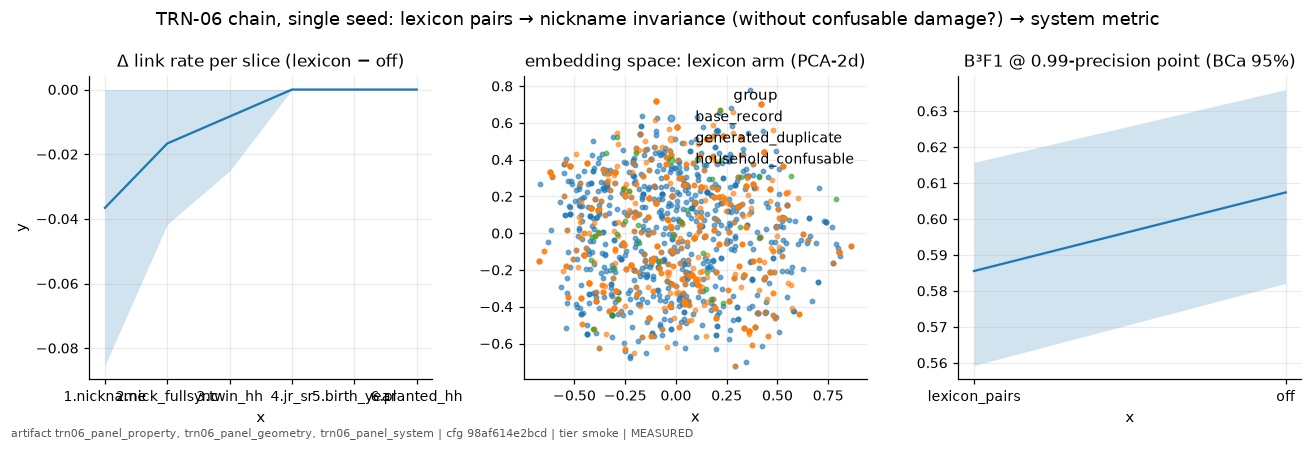

In [22]:
# The TRN-06 triptych: BOTH slices visible in one property panel — the per-slice
# at-threshold link-rate delta (lexicon minus off). The nickname slices should sit
# above zero; every must-not slice should hug it.
SLICE_ORDER = [
    ("1.nickname", "nickname_swap"), ("2.nick_fullsync", "nickname_fullsync"),
    ("3.twin_hh", "twin_household"), ("4.jr_sr", "suffix_jr_sr"),
    ("5.birth_year", "different_birth_year"), ("6.planted_hh", "planted_household"),
]
prop_frame = pd.DataFrame([
    {"x": label, "y": prop_deltas[key]["delta"],
     "lo": prop_deltas[key]["lo"], "hi": prop_deltas[key]["hi"],
     "side": "should_hold" if key.startswith("nickname") else "must_not_hold"}
    for label, key in SLICE_ORDER if key in prop_deltas
])
geo_xy = pca2(lex["geo_emb"])
geo_frame = pd.DataFrame({"x": geo_xy[:, 0], "y": geo_xy[:, 1], "group": GEO_KIND})
scr06 = trn06[(trn06["factor"] == "nickname_supervision")
              & (~trn06["arm"].str.contains("@"))]
sys_frame = scr06[["arm", "f1", "f1_lo", "f1_hi"]].rename(
    columns={"arm": "x", "f1": "y", "f1_lo": "lo", "f1_hi": "hi"})
registry.register("trn06_panel_property", prop_frame, cfg=cfg, tier=cfg.run.tier,
                  meta={"note": "TRN-06 triptych left: at-threshold link-rate delta "
                                "(lexicon - off) per slice, pair-bootstrap 95% CI; "
                                "slices 1-2 should rise, 3-6 must not"})
registry.register("trn06_panel_geometry", geo_frame, cfg=cfg, tier=cfg.run.tier,
                  meta={"note": "TRN-06 triptych middle: PCA-2d of the lexicon arm's "
                                "eval-sample embeddings, colored by record kind"})
registry.register("trn06_panel_system", sys_frame, cfg=cfg, tier=cfg.run.tier,
                  meta={"note": "TRN-06 triptych right: B3F1 + entity BCa CI per "
                                "supervision arm (scratch-char)"})
fig = figures.three_panel_pressure(
    registry, tier=cfg.run.tier,
    property_shift="trn06_panel_property", geometry="trn06_panel_geometry",
    system_metric="trn06_panel_system",
    titles=("Δ link rate per slice (lexicon − off)",
            "embedding space: lexicon arm (PCA-2d)",
            "B³F1 @ 0.99-precision point (BCa 95%)"),
    suptitle="TRN-06 chain, single seed: lexicon pairs → nickname invariance "
             "(without confusable damage?) → system metric",
)

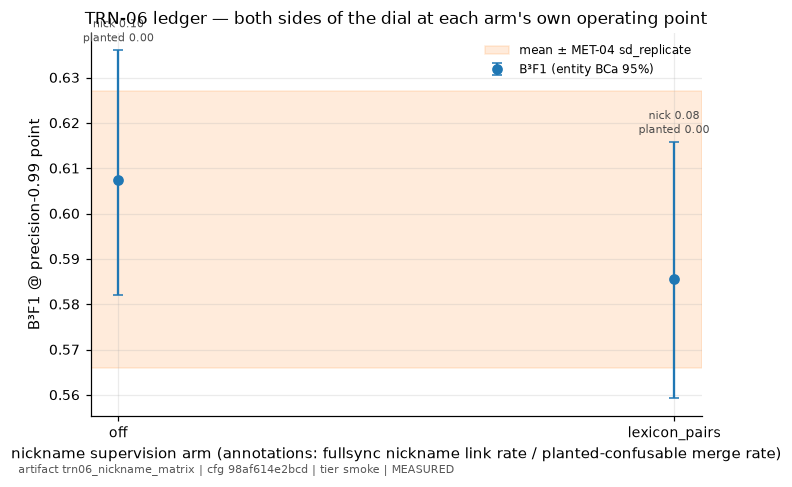

In [23]:
def draw_trn06_ledger(ax, df, meta):
    d = df[(df["factor"] == "nickname_supervision")
           & (~df["arm"].astype(str).str.contains("@"))].reset_index(drop=True)
    sd = float(meta["extra"]["met04_sd_replicate"])
    mean_f1 = float(d["f1"].mean())
    ax.axhspan(mean_f1 - sd, mean_f1 + sd, color="C1", alpha=0.15,
               label="mean ± MET-04 sd_replicate")
    yerr = np.vstack([np.clip(d["f1"] - d["f1_lo"], 0, None),
                      np.clip(d["f1_hi"] - d["f1"], 0, None)])
    ax.errorbar(d["arm"], d["f1"], yerr=yerr, fmt="o", capsize=3, markersize=6,
                color="C0", label="B³F1 (entity BCa 95%)")
    for x, (_, r) in zip(d["arm"], d.iterrows()):
        ax.annotate(f"nick {r['nickfs_link_rate']:.2f}\nplanted {r['hh_merge_rate']:.2f}",
                    (x, float(r["f1_hi"])), textcoords="offset points", xytext=(0, 6),
                    ha="center", fontsize=7.5, color="0.3")
    ax.set_xlabel("nickname supervision arm (annotations: fullsync nickname link rate / "
                  "planted-confusable merge rate)")
    ax.set_ylabel(f"B³F1 @ precision-{PREC_TARGET} point")
    ax.legend(loc="best", fontsize=8)


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="trn06_nickname_matrix",
    draw=draw_trn06_ledger,
    title="TRN-06 ledger — both sides of the dial at each arm's own operating point",
    figsize=(6.6, 4.4),
)

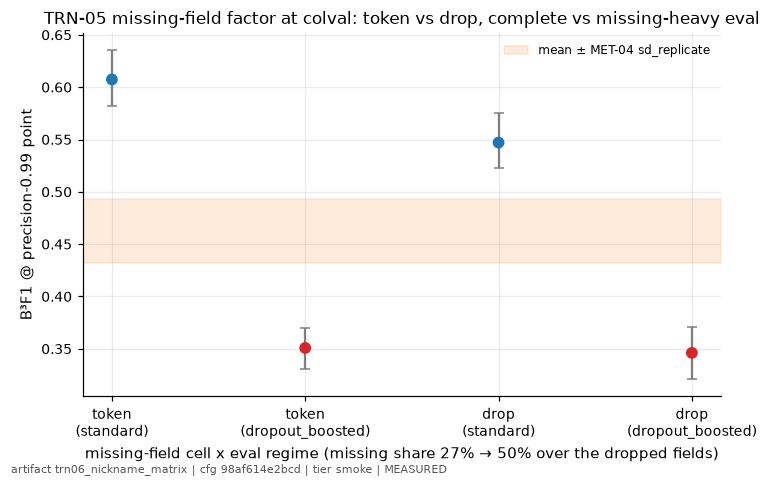

In [24]:
def draw_missing_ledger(ax, df, meta):
    d = df[df["factor"] == "missing_field"].reset_index(drop=True)
    labels = [f"{r['arm']}\n({r['eval_regime']})" for _, r in d.iterrows()]
    yerr = np.vstack([np.clip(d["f1"] - d["f1_lo"], 0, None),
                      np.clip(d["f1_hi"] - d["f1"], 0, None)])
    colors = ["C0" if r["eval_regime"] == "standard" else "C3" for _, r in d.iterrows()]
    ax.errorbar(labels, d["f1"], yerr=yerr, fmt="none", ecolor="0.5", capsize=3)
    ax.scatter(labels, d["f1"], c=colors, s=45, zorder=5)
    sd = float(meta["extra"]["met04_sd_replicate"])
    mean_f1 = float(d["f1"].mean())
    ax.axhspan(mean_f1 - sd, mean_f1 + sd, color="C1", alpha=0.15,
               label="mean ± MET-04 sd_replicate")
    ms = meta["extra"]["missing_stress"]["missing_share_before_after"]
    ax.set_xlabel(f"missing-field cell x eval regime (missing share "
                  f"{ms[0]:.0%} → {ms[1]:.0%} over the dropped fields)")
    ax.set_ylabel(f"B³F1 @ precision-{PREC_TARGET} point")
    ax.legend(loc="best", fontsize=8)


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="trn06_nickname_matrix",
    draw=draw_missing_ledger,
    title=f"TRN-05 missing-field factor at {WIN_SCHEME}: token vs drop, "
          "complete vs missing-heavy eval",
    figsize=(7.0, 4.4),
)

In [25]:
# [RUN-IN-TARGET node] definitive TRN-06: the locked 2x2 (supervision x regime) x
# replicates from met04_power_table, plus a supervision-DOSE dial (pool fraction
# 0 -> measured -> 2x) for the mediation analysis PLAN §5 requires — none of which one
# smoke seed can license.
if TIER in ("mid", "target"):
    print(f"tier={TIER}: rows above are definitive-tier cells for the regimes that "
          "ran; replicate counts come from met04_power_table at this tier.")
else:
    n_star = SEEDS_NEEDED.get(0.02, 5)
    per_arm = float(np.nanmean([r["train_secs"] for r in trn06_rows]))
    runs = 4 * n_star
    est_h = runs * per_arm * (STEPS_BY_TIER["target"] / STEPS) / 3600
    print(f"[RUN-IN-TARGET node] definitive TRN-06 = 4 cells x n*={n_star} replicates "
          f"= {runs} runs (+ dose-dial arms). Measured mean scratch-arm cost here: "
          f"{per_arm:.0f}s at {STEPS} steps -> naive linear scaling to "
          f"{STEPS_BY_TIER['target']} steps gives ~{est_h:.0f} container-hours; the "
          "node's A100s are the intended home. TRN-05/06 are LAST in PLAN §3's "
          "protected-arm priority (TRN-02 > TRN-03 chain > TRN-04 > TRN-01 > "
          "TRN-05/06) — first to be cut if the power table forces pruning.")

[RUN-IN-TARGET node] definitive TRN-06 = 4 cells x n*=19 replicates = 76 runs (+ dose-dial arms). Measured mean scratch-arm cost here: 34s at 250 steps -> naive linear scaling to 4000 steps gives ~12 container-hours; the node's A100s are the intended home. TRN-05/06 are LAST in PLAN §3's protected-arm priority (TRN-02 > TRN-03 chain > TRN-04 > TRN-01 > TRN-05/06) — first to be cut if the power table forces pruning.


### 5a. Verdict — TRN-06

In [26]:
r_off = scr06[scr06["arm"] == "off"].iloc[0]
r_lex = scr06[scr06["arm"] == "lexicon_pairs"].iloc[0]
d_nick = prop_deltas["nickname_fullsync"]
p1_gain = d_nick["lo"] > 0
harm_names = [n for n in ("twin_household", "suffix_jr_sr", "different_birth_year",
                          "planted_household") if n in prop_deltas]
harms = {n: prop_deltas[n] for n in harm_names}
p2_rate_damage = [n for n, d in harms.items() if d["lo"] > 0]
auc_drops = {n: float(r_off[c] - r_lex[c])
             for n, c in (("twin_household", "twin_auc"), ("suffix_jr_sr", "jrsr_auc"),
                          ("different_birth_year", "dob_auc"))}
p2_auc_damage = [n for n, v in auc_drops.items() if v > 0.05]
p2_guard = not p2_rate_damage and not p2_auc_damage
p3_ok = d_sys06["delta"] > -DETECT_BAR
if p1_gain and not p2_guard:
    trn06_outcome = "REFUTED"  # the teaching-mistakes outcome
elif p1_gain and p2_guard and p3_ok:
    trn06_outcome = "CONFIRMED"
else:
    trn06_outcome = "UNEXPLAINED"
print(f"P1 nickname gain (fullsync link-rate delta): {d_nick['delta']:+.3f} "
      f"[{d_nick['lo']:+.3f},{d_nick['hi']:+.3f}] -> CI>0: {p1_gain} "
      f"(stale-full_name slice: {prop_deltas['nickname_swap']['delta']:+.3f})")
print(f"P2 guard: rate-damage slices {p2_rate_damage or 'none'}; AUC drops >0.05: "
      f"{p2_auc_damage or 'none'} (deltas {({k: round(v, 3) for k, v in auc_drops.items()})})")
print(f"P3 system: paired delta {d_sys06['delta']:+.4f} vs -bar {-DETECT_BAR:.4f} -> "
      f"not degraded beyond bar: {p3_ok}")

_ = verdict_box(
    "TRN-06",
    outcome=trn06_outcome,
    evidence=(
        f"trn06_nickname_matrix + trn06_panel_* (tier {TIER}, scratch-char, 1 seed, "
        f"{STEPS} matched steps; realized supervision dose "
        f"{SUP_PAIR_FRACTION:.1%} of the training pair pool, {len(SWAPPED_IDS)} "
        f"swapped records). P1: full_name-synced nickname link-rate delta "
        f"{d_nick['delta']:+.3f} [{d_nick['lo']:+.3f},{d_nick['hi']:+.3f}] "
        f"({'gain CI excludes zero' if p1_gain else 'CI includes zero — no scoreable gain at this dose/seed'}); "
        f"stale-full_name battery slice {prop_deltas['nickname_swap']['delta']:+.3f} "
        f"(kept for NB08 comparability). P2: at-threshold damage CIs excluding zero on "
        f"{p2_rate_damage if p2_rate_damage else 'NO must-not slice'} "
        f"(planted household confusables: merge rate {r_off['hh_merge_rate']:.2f} -> "
        f"{r_lex['hh_merge_rate']:.2f}, delta "
        f"{prop_deltas['planted_household']['delta']:+.3f} "
        f"[{prop_deltas['planted_household']['lo']:+.3f},"
        f"{prop_deltas['planted_household']['hi']:+.3f}]); AUC drops beyond 0.05: "
        f"{p2_auc_damage if p2_auc_damage else 'none'}; the suffix_jr_sr guard is LIVE "
        f"via the NB08 role-admitting probe serializer (jrsr AUC {r_off['jrsr_auc']:.3f} "
        f"-> {r_lex['jrsr_auc']:.3f}); probe slices with no live pairs: "
        f"{empty_slices or 'none'}. "
        f"P3: paired B3F1 delta "
        f"{d_sys06['delta']:+.4f} [{d_sys06['ci_low']:+.4f},{d_sys06['ci_high']:+.4f}] "
        f"vs MET-04 bars {DETECT_BAR:.4f} (pre-registered, scores the rule) / "
        f"{DETECT_BAR_RESID:.4f} (residual-inclusive, primary honest lens) "
        f"({BAR_SOURCE.split(' run ')[0]}). "
        f"By the pre-registered rule this scores {trn06_outcome}"
        + (" — a gain on one side with damage on the other would REFUTE, and did not "
           "occur at this seed" if trn06_outcome != "REFUTED" else
           " — the gain came WITH confusable damage: supervision taught the mistake") +
        f". SMOKE SCOPE: one seed, {int(ev_slice['entity_id'].nunique())} eval "
        "entities, English-centric lexicon (documented provenance bias), pretrained "
        "regime cells absent at smoke (mac placard). Mediation supervision -> "
        "invariance -> F1: UNEXPLAINED by design at one seed — the two marginal "
        "effects are reported separately, never as mediation (PLAN §5); the node 2x2 "
        "with the dose dial is the definitive test."
    ),
    registry=registry,
)

P1 nickname gain (fullsync link-rate delta): -0.017 [-0.042,+0.000] -> CI>0: False (stale-full_name slice: -0.037)
P2 guard: rate-damage slices none; AUC drops >0.05: none (deltas {'twin_household': -0.014, 'suffix_jr_sr': 0.005, 'different_birth_year': 0.005})
P3 system: paired delta -0.0218 vs -bar -0.0862 -> not degraded beyond bar: True


> ### VERDICT: UNEXPLAINED — card `TRN-06`
>
> **Conjecture** Lexicon-pair nickname supervision teaches the nuance without the mistake: swapping a documented fraction of training positives for lexicon-generated nickname pairs makes the encoder nickname-invariant where it should be, WITHOUT transferring 'different given name, same person' to the confusable slices where a small name difference is the only thing separating two real people (twins/households, Jr vs Sr, adjacent birth years).
>
> **Prediction** P1 (the gain): the lexicon arm raises the nickname-slice at-threshold link rate, pair-bootstrap 95% CI excluding zero, on the full_name-synced slice at minimum. P2 (the guard): no must-not-hold damage — the planted-confusable merge rate and the three confusable false-link rates do not rise with CI excluding zero, and confusable AUCs do not drop by more than 0.05. P3 (system): B-cubed F1 does not degrade beyond the MET-04 single-seed bar. Decision rule, pre-registered: CONFIRMED requires P1 AND P2 (with P3 not violated); a P1 gain accompanied by P2 damage REFUTES (that is the teaching-mistakes outcome, and finding it is the point); anything short of P1's CI is UNEXPLAINED at one seed. English-lexicon provenance bias is a standing limitation on any confirmation. Mediation (supervision -> nickname invariance -> F1) is not claimable from one seed and is not claimed.
>
> **Evidence** trn06_nickname_matrix + trn06_panel_* (tier smoke, scratch-char, 1 seed, 250 matched steps; realized supervision dose 4.1% of the training pair pool, 136 swapped records). P1: full_name-synced nickname link-rate delta -0.017 [-0.042,+0.000] (CI includes zero — no scoreable gain at this dose/seed); stale-full_name battery slice -0.037 (kept for NB08 comparability). P2: at-threshold damage CIs excluding zero on NO must-not slice (planted household confusables: merge rate 0.00 -> 0.00, delta +0.000 [+0.000,+0.000]); AUC drops beyond 0.05: none; the suffix_jr_sr guard is LIVE via the NB08 role-admitting probe serializer (jrsr AUC 0.109 -> 0.104); probe slices with no live pairs: none. P3: paired B3F1 delta -0.0218 [-0.0367,-0.0149] vs MET-04 bars 0.0862 (pre-registered, scores the rule) / 0.0865 (residual-inclusive, primary honest lens) (met04_power_table). By the pre-registered rule this scores UNEXPLAINED — a gain on one side with damage on the other would REFUTE, and did not occur at this seed. SMOKE SCOPE: one seed, 300 eval entities, English-centric lexicon (documented provenance bias), pretrained regime cells absent at smoke (mac placard). Mediation supervision -> invariance -> F1: UNEXPLAINED by design at one seed — the two marginal effects are reported separately, never as mediation (PLAN §5); the node 2x2 with the dose dial is the definitive test.


### 5b. Verdict — the missing-field factor under stress

In [27]:
p1_tok = d_boost["sign_stable"] and d_boost["delta"] > 0
p2_inter = (d_boost["delta"] - d_std["delta"]) > 0
refuted_ms = d_boost["sign_stable"] and d_boost["delta"] < 0
if refuted_ms:
    ms_outcome = "REFUTED"
elif p1_tok and p2_inter:
    ms_outcome = "CONFIRMED"
else:
    ms_outcome = "UNEXPLAINED"
_ = verdict_box(
    "TRN-05-MISSING-STRESS",
    outcome=ms_outcome,
    evidence=(
        f"trn06_nickname_matrix factor='missing_field' rows (tier {TIER}, scheme "
        f"{WIN_SCHEME}, 1 seed, {STEPS} matched steps; token cell "
        f"{'reused from the control arm — identical configuration, stated' if tok_reuse else 'trained fresh'}; "
        f"eval missing share {missing_share(ev_slice):.1%} -> "
        f"{missing_share(boost_ev):.1%} over {list(DROP_FIELDS)}). P1: token-minus-drop "
        f"paired delta on the BOOSTED eval {d_boost['delta']:+.4f} "
        f"[{d_boost['ci_low']:+.4f},{d_boost['ci_high']:+.4f}] "
        f"(sign_stable={d_boost['sign_stable']}); standard-eval gap {d_std['delta']:+.4f} "
        f"[{d_std['ci_low']:+.4f},{d_std['ci_high']:+.4f}]. P2 interaction "
        f"(boosted - standard gap) = {d_boost['delta'] - d_std['delta']:+.4f} "
        f"({'token advantage widens under missingness' if p2_inter else 'no widening at this seed'}). "
        f"MET-04 bars for single-seed margins: {DETECT_BAR:.4f} (pre-registered) / "
        f"{DETECT_BAR_RESID:.4f} (residual-inclusive, primary honest lens). {ORDER_NOTE}. "
        "SMOKE SCOPE: one seed, synthetic missingness stress (openly labeled — the "
        "corpus's measured dropout floor is ~1e-5 and bounds entry-error missingness "
        "only from below); the multi-seed 8-cell factorial x missingness ladder at mid "
        "(mac placard) is the definitive test. Mediation through the serialization "
        "properties: UNEXPLAINED at one seed, not claimed."
    ),
    registry=registry,
)
tick("§5 matrix + verdicts", t_sec)

> ### VERDICT: UNEXPLAINED — card `TRN-05-MISSING-STRESS`
>
> **Conjecture** Notebook 08's missing-field factor was scored on a nearly-complete corpus, where the {token, drop} treatments barely differ at eval time; under a missing-heavy eval stream the treatments separate, and the visible [MISSING] token holds up better than silently dropping fields, because token-serialized records keep field identity and string geometry stable as cells vanish.
>
> **Prediction** P1: on the dropout-boosted eval, token beats drop with the paired entity-bootstrap delta excluding zero. P2 (interaction): the token-minus-drop gap is larger on the boosted eval than on the standard eval. Decision rule: P1's paired CI is the primary test, read alongside the MET-04 bar; a sign-stable drop-beats-token on the boosted eval REFUTES; single-seed margins inside both are UNEXPLAINED — the definitive answer is the multi-seed 8-cell factorial at mid (placard).
>
> **Evidence** trn06_nickname_matrix factor='missing_field' rows (tier smoke, scheme colval, 1 seed, 250 matched steps; token cell reused from the control arm — identical configuration, stated; eval missing share 26.8% -> 50.5% over ['dob', 'city', 'zip', 'sex', 'occupation']). P1: token-minus-drop paired delta on the BOOSTED eval +0.0047 [-0.0132,+0.0207] (sign_stable=False); standard-eval gap +0.0603 [+0.0472,+0.0812]. P2 interaction (boosted - standard gap) = -0.0556 (no widening at this seed). MET-04 bars for single-seed margins: 0.0862 (pre-registered) / 0.0865 (residual-inclusive, primary honest lens). winning-08 scheme = colval (trn05_serialization_matrix run 2026-08-29T15:46:27.250842+00:00, best token-arm B3F1 0.6377). SMOKE SCOPE: one seed, synthetic missingness stress (openly labeled — the corpus's measured dropout floor is ~1e-5 and bounds entry-error missingness only from below); the multi-seed 8-cell factorial x missingness ladder at mid (mac placard) is the definitive test. Mediation through the serialization properties: UNEXPLAINED at one seed, not claimed.


[section timing] §5 matrix + verdicts: 1s


## 6. LABEL-PROV — the circular teacher, demonstrated live

### 6a. Which teacher is even available?

The honest wiring problem comes first. The natural teacher is notebook 06's tuned
Fellegi–Sunter scorer, and its scored pairs ARE registered (`bas01_scored_pairs`) —
but that artifact scores the **entity-disjoint eval half** (its meta says so), and
training a student on eval-half records would put the same entities on both sides of
the train/eval boundary: exactly the leak MET-07 exists to forbid. So the teacher
that *labels the training slice* is an in-notebook FS stand-in — mean Jaro–Winkler
over `given_name`/`family_name`/`city` plus exact-match indicators on `dob`/`zip`,
over matchkey-blocked candidate pairs (the same blocking family notebook 06 used) —
and the stand-in is *validated against* the registered FS scores on shared eval-half
pairs before it is trusted to teach. The teacher's operating point is its own
precision-0.99 threshold, tuned charitably on train-slice truth: every label error
that survives is the teacher's irreducible blind spot, not a tuning artifact.

In [28]:
t_sec = time.time()
JW_FIELDS_FUZZY = ("given_name", "family_name", "city")
JW_FIELDS_EXACT = ("dob", "zip")


def jw_teacher_scores(frame: pd.DataFrame, pairs: pd.DataFrame) -> np.ndarray:
    """Mean JW(fuzzy fields) + equality(exact fields), fields present in BOTH records."""
    recs = frame.set_index(frame["record_id"].astype(str))
    a = recs.loc[pairs["a"].astype(str)]
    b = recs.loc[pairs["b"].astype(str)]
    scores = np.zeros(len(pairs))
    counts = np.zeros(len(pairs))
    for fld in JW_FIELDS_FUZZY + JW_FIELDS_EXACT:
        va = a[fld].astype("string").to_numpy()
        vb = b[fld].astype("string").to_numpy()
        ok = ~(pd.isna(va) | pd.isna(vb))
        sim = np.zeros(len(pairs))
        if fld in JW_FIELDS_FUZZY:
            sim[ok] = [jellyfish.jaro_winkler_similarity(str(x), str(y))
                       for x, y in zip(va[ok], vb[ok])]
        else:
            sim[ok] = (va[ok] == vb[ok]).astype(float)
        scores += np.where(ok, sim, 0.0)
        counts += ok.astype(float)
    return np.where(counts > 0, scores / np.maximum(counts, 1), 0.0)


HAVE_BAS01 = registry.exists("bas01_scored_pairs", tier=cfg.run.tier)
if HAVE_BAS01:
    bas01, bas01_meta = registry.load("bas01_scored_pairs", tier=cfg.run.tier)
    print(f"bas01_scored_pairs: present ({len(bas01):,} pairs) — but its meta scopes it "
          "to the ENTITY-DISJOINT EVAL HALF; using it as training supervision would "
          "train and evaluate on overlapping entities. RAIL: it validates the stand-in "
          "teacher below; it does not label the training slice.")
    in_train = (bas01["a"].astype(str).isin(set(train_slice["record_id"].astype(str)))
                | bas01["b"].astype(str).isin(set(train_slice["record_id"].astype(str))))
    print(f"  (checked live: {int(in_train.sum())} of its pairs touch this train slice)")
    _val = bas01.iloc[np.sort(np.random.default_rng(PRIMARY_SEED + 51).choice(
        len(bas01), size=min(20_000, len(bas01)), replace=False))]
    _jw_val = jw_teacher_scores(eval_full, _val)
    _rho = float(pd.Series(_jw_val).corr(pd.Series(_val["prob"].to_numpy()),
                                         method="spearman"))
    _fs_link = _val["prob"].to_numpy() >= 0.5
    _dec_auc = (float(roc_auc_score(_fs_link, _jw_val))
                if 0 < _fs_link.sum() < len(_fs_link) else float("nan"))
    TEACHER_KIND = f"jw_mean stand-in (validated vs bas01 FS: spearman {_rho:.3f})"
    print(f"  stand-in validation on {len(_val):,} shared eval-half pairs: spearman "
          f"rho={_rho:.3f} vs FS probabilities; AUC of JW scores against FS link "
          f"decisions {_dec_auc:.3f} -> the JW-mean teacher is an imperfect but "
          "FS-shaped proxy")
else:
    TEACHER_KIND = "jw_mean stand-in (bas01_scored_pairs absent at this tier — unvalidated)"
    print("!! bas01_scored_pairs absent at this tier (notebook 06 still building) — "
          "the JW-mean stand-in runs unvalidated; re-run after 06 for the validation.")

bas01_scored_pairs: present (105,285 pairs) — but its meta scopes it to the ENTITY-DISJOINT EVAL HALF; using it as training supervision would train and evaluate on overlapping entities. RAIL: it validates the stand-in teacher below; it does not label the training slice.
  (checked live: 0 of its pairs touch this train slice)
  stand-in validation on 20,000 shared eval-half pairs: spearman rho=0.718 vs FS probabilities; AUC of JW scores against FS link decisions 0.962 -> the JW-mean teacher is an imperfect but FS-shaped proxy


In [29]:
# Teacher labels for the training slice: matchkey candidates -> JW-mean scores ->
# precision-0.99 threshold (charitable truth-tuned setting, documented) -> transitive
# closure -> predicted clusters. The measured label-noise dose follows.
TRUTH_TR = train_slice.set_index("record_id")["entity_id"]
RECORDS_TR = pd.Index(TRUTH_TR.index)
t_cand = matchkeys.candidates(train_slice)
t_scores = jw_teacher_scores(train_slice, t_cand)
t_scored = pd.DataFrame({"a": t_cand["a"], "b": t_cand["b"], "prob": t_scores})
_t_cache: dict[float, pd.Series] = {}


def t_clusterer(t: float) -> pd.Series:
    if t not in _t_cache:
        _t_cache[t] = transitive_closure(t_scored, threshold=float(t), records=RECORDS_TR)
    return _t_cache[t]


t_res = find_threshold_for_precision(
    t_scored.rename(columns={"prob": "score"}), t_clusterer, TRUTH_TR,
    target=PREC_TARGET, grid=GRID,
)
if not t_res["attained"]:
    print(f"!! teacher precision {PREC_TARGET} UNATTAINABLE on the train slice — "
          f"teaching from the highest-attainable point P={t_res['attained_precision']:.4f} "
          f"(fallback='{t_res['fallback']}'; PLAN §5 rail: loud, never silent)")
TEACH_THR = float(t_res["threshold"])
teacher_labels = t_clusterer(TEACH_THR)
t_pw = pairwise(teacher_labels, TRUTH_TR)
_tsizes = teacher_labels.value_counts()
share_in_multi = float(teacher_labels.map(_tsizes).ge(2).mean())
print(f"teacher: {TEACHER_KIND}")
print(f"  {len(t_scored):,} matchkey candidate pairs; threshold {TEACH_THR:.4f} "
      f"(attained P {t_res['attained_precision']:.4f}, pair recall at threshold "
      f"{t_res['recall_at']:.4f})")
print(f"  label-noise dose vs truth (pairwise): precision {t_pw['precision']:.4f}, "
      f"recall {t_pw['recall']:.4f} — the teacher MISSES "
      f"{1 - t_pw['recall']:.0%} of true training pairs (FN-dominated noise, the "
      "lit_review §8 signature) and invents "
      f"{int(t_pw['fp'])} false ones")
print(f"  clusters: {teacher_labels.nunique():,} predicted vs "
      f"{TRUTH_TR.nunique():,} true entities; {share_in_multi:.0%} of records sit in a "
      "multi-record teacher cluster (the loop's positive-pair supply)")
tick("§6a teacher construction", t_sec)

teacher: jw_mean stand-in (validated vs bas01 FS: spearman 0.718)
  18,786 matchkey candidate pairs; threshold 0.2198 (attained P 0.9926, pair recall at threshold 0.6353)
  label-noise dose vs truth (pairwise): precision 0.9797, recall 0.5840 — the teacher MISSES 42% of true training pairs (FN-dominated noise, the lit_review §8 signature) and invents 431 false ones
  clusters: 748 predicted vs 222 true entities; 83% of records sit in a multi-record teacher cluster (the loop's positive-pair supply)
[section timing] §6a teacher construction: 1s


### 6b. Two students, one budget, judged on truth

Student A trains on true `entity_id` pairs — it *is* the TRN-06 control arm
(identical configuration: same corpus slice, labels, init seed, step budget; reuse
stated, notebook-09 convention). Student B trains on the teacher's predicted
clusters: `entity_id` is replaced by the teacher's cluster label and NOTHING else
changes — same records, same encoder init, same steps. Both are then scored by the
shared recipe on the truth-labeled, entity-disjoint eval slice the teacher never
touched.

In [30]:
t_sec = time.time()
studentB_slice = train_slice.copy()
studentB_slice["entity_id"] = (
    "t_" + studentB_slice["record_id"].astype(str).map(teacher_labels).astype(str)
)
encB, histB, secsB, ihashB = train_arm(studentB_slice, seed=PRIMARY_SEED)
# identical init across the provenance arms — asserted (student A reuses trn06/off)
assert ihashB == trn06_rows[0]["init_hash"], (
    f"students must share one initialization, got A={trn06_rows[0]['init_hash']} "
    f"B={ihashB}"
)
print(f"student B loss {histB['loss'].iloc[0]:.3f} -> {histB['loss'].tail(20).mean():.3f} "
      f"| init {ihashB} (matches student A's — asserted)")
sysB = system_metric(encB, label="labelprov/studentB")
sysA = {k: arm_state["trn06/off"]["row"][k]
        for k in ("f1", "f1_lo", "f1_hi", "recall_at", "attained_precision",
                  "attained", "threshold", "n_candidate_pairs")}
sysA["pred"], sysA["emb"] = arm_state["trn06/off"]["pred"], arm_state["trn06/off"]["emb"]
assert len(histB) == trn06_rows[0]["steps"], "students must share one step budget"
d_ab = paired_delta(sysA["pred"], sysB["pred"], TRUTH_EV, "bcubed_f1",
                    unit="entity", n_boot=N_BOOT, seed=PRIMARY_SEED)
print(f"student A (truth labels; reuses trn06/off, identical configuration, stated): "
      f"B3F1={sysA['f1']:.4f} [{sysA['f1_lo']:.4f},{sysA['f1_hi']:.4f}]")
print(f"student B (teacher labels): B3F1={sysB['f1']:.4f} "
      f"[{sysB['f1_lo']:.4f},{sysB['f1_hi']:.4f}] (P {sysB['attained_precision']:.4f}, "
      f"R {sysB['recall_at']:.4f}) train {secsB:.0f}s")
print(f"A - B paired delta: {d_ab['delta']:+.4f} [{d_ab['ci_low']:+.4f},"
      f"{d_ab['ci_high']:+.4f}] sign_stable={d_ab['sign_stable']}; "
      f"MET-04 bar {DETECT_BAR:.4f}")
tick("§6b students", t_sec)

student B loss 4.684 -> 0.948 | init cef0494ec267 (matches student A's — asserted)


student A (truth labels; reuses trn06/off, identical configuration, stated): B3F1=0.6074 [0.5821,0.6360]
student B (teacher labels): B3F1=0.5330 [0.5096,0.5609] (P 0.9984, R 0.3635) train 34s
A - B paired delta: +0.0744 [+0.0567,+0.0968] sign_stable=True; MET-04 bar 0.0862
[section timing] §6b students: 38s


### 6c. Where does the loss land? The teacher-agreement strata

The concentration claim needs a *shared, encoder-independent* pair sample, each pair
labeled true/false by eval truth and right/wrong by the SAME teacher at the SAME
threshold (pair-level decision — no closure, so a pair's stratum depends only on the
teacher, never on either student). Two subtleties the machinery has to respect:

1. **The teacher's decision is blocking-aware.** An FS teacher never scores a pair
   its blocking excluded — its implicit decision there is *no-link*. So the teacher
   decision here is `in matchkey blocking AND score >= threshold`, and a true pair
   the blocking misses counts as a teacher miss: with NB06-measured pair
   completeness ~0.53, blocking misses are the teacher's DOMINANT error channel, and
   they are exactly the positives student B was never shown.
2. **The sample must carry every pair kind.** This corpus is so dedup-dense that
   blocked pairs are almost entirely true pairs. The sample is therefore a
   documented four-source union: **matchkey candidates** (realistic blocked pairs),
   **sampled same-entity true pairs** (surfacing the out-of-block missed matches),
   **planted household-confusable pairs** (hard false pairs with both sides in this
   slice), and **seeded random cross-entity pairs** (the easy-negative floor).

For each student x stratum: the true-vs-false AUC of the student's cosines. If
teacher-taught damage concentrates on hard pairs, student B's AUC deficit should be
larger on the teacher-wrong stratum — the pairs whose kind the teacher mislabeled in
training are the pairs the student can no longer separate at eval.

**Instrument refinement, stated openly.** The registered LABEL-PROV card's property
field describes the pair sample as three sources with a raw-threshold teacher
decision — the instrument as first designed. Building it exposed the two mechanical
flaws above (a raw threshold "scores" pairs the teacher's blocking would never show
it; the teacher's dominant error channel was absent from the sample), so the
measurement below uses the corrected four-source, blocking-aware form. The card is
kept verbatim per PLAN §5 immutability — a card is never edited after first render —
and this refinement changes the measurement machinery only: the conjecture, the
metric, and the pre-registered P1/P2 decision rule are untouched, and the
refinement was fixed before this notebook's results existed.

In [31]:
t_sec = time.time()
_ev_rids = ev_slice["record_id"].astype(str)
_epos = {rid: i for i, rid in enumerate(_ev_rids)}
mk_pairs = matchkeys.candidates(ev_slice)[["a", "b"]].assign(source="matchkey")
_tp_ev = build_pairs_inbatch(ev_slice, n_pairs=len(mk_pairs), seed=PRIMARY_SEED + 62)
true_pairs_ev = (_tp_ev.rename(columns={"a_id": "a", "b_id": "b"})[["a", "b"]]
                 .assign(source="true_pair"))
_in_ev = HH_PAIRS["confusable_id"].isin(_epos) & HH_PAIRS["base_id"].isin(_epos)
hh_in = (HH_PAIRS.loc[_in_ev, ["confusable_id", "base_id"]]
         .rename(columns={"confusable_id": "a", "base_id": "b"})
         .assign(source="planted_household"))
_rng_neg = np.random.default_rng(PRIMARY_SEED + 63)
_ent_arr = ev_slice["entity_id"].to_numpy()
_ii = _rng_neg.integers(0, len(ev_slice), size=3 * len(mk_pairs))
_jj = _rng_neg.integers(0, len(ev_slice), size=3 * len(mk_pairs))
_keep = (_ii != _jj) & (_ent_arr[_ii] != _ent_arr[_jj])
rand_pairs = (pd.DataFrame({"a": _ev_rids.to_numpy()[_ii[_keep]],
                            "b": _ev_rids.to_numpy()[_jj[_keep]]})
              .head(len(mk_pairs)).assign(source="random_negative"))
# priority order matters: a pair found by blocking keeps source='matchkey', so
# BLOCKED == (source == 'matchkey') after the dedup below.
e_cand = pd.concat([mk_pairs, true_pairs_ev, hh_in, rand_pairs], ignore_index=True)
_sw = e_cand["a"].astype(str) > e_cand["b"].astype(str)
e_cand.loc[_sw, ["a", "b"]] = e_cand.loc[_sw, ["b", "a"]].to_numpy()
e_cand = e_cand.drop_duplicates(subset=["a", "b"]).reset_index(drop=True)
e_scores = jw_teacher_scores(ev_slice, e_cand)
_eia = e_cand["a"].astype(str).map(_epos).to_numpy()
_eib = e_cand["b"].astype(str).map(_epos).to_numpy()
is_true = (_ent_arr[_eia] == _ent_arr[_eib])
in_block = (e_cand["source"] == "matchkey").to_numpy()
t_says_link = in_block & (e_scores >= TEACH_THR)  # blocking-aware teacher decision
t_correct = t_says_link == is_true
cosA = np.einsum("ij,ij->i", sysA["emb"][_eia], sysA["emb"][_eib])
cosB = np.einsum("ij,ij->i", sysB["emb"][_eia], sysB["emb"][_eib])
print(f"eval strata sample: {len(e_cand):,} pairs "
      f"({e_cand['source'].value_counts().to_dict()}; {int(is_true.sum()):,} true)")
print(f"teacher pair-accuracy {t_correct.mean():.1%} — wrong on "
      f"{int((~t_correct).sum()):,} pairs: "
      f"{int((~t_correct & is_true).sum()):,} missed matches "
      f"({int((~t_correct & is_true & ~in_block).sum()):,} of them blocking misses — "
      f"the dominant channel), {int((~t_correct & ~is_true).sum()):,} false links "
      f"(by source: "
      f"{e_cand.loc[~t_correct & ~is_true, 'source'].value_counts().to_dict()})")


def stratum_auc(cos: np.ndarray, mask: np.ndarray) -> float:
    y = is_true[mask]
    if y.all() or (~y).all():
        return float("nan")
    return float(roc_auc_score(y, cos[mask]))


def _auc_at(cos: np.ndarray, idx: np.ndarray) -> float:
    """AUC over an index array WITH multiplicity — the bootstrap-correct form."""
    y = is_true[idx]
    if y.all() or (~y).all():
        return float("nan")
    return float(roc_auc_score(y, cos[idx]))


strata_rows: list[dict] = []
for student, cos_s in (("A_truth", cosA), ("B_teacher", cosB)):
    for stratum, mask in (("teacher_right", t_correct), ("teacher_wrong", ~t_correct)):
        strata_rows.append({
            "kind": "strata", "student": student, "stratum": stratum,
            "n_pairs": int(mask.sum()), "n_true": int(is_true[mask].sum()),
            "n_false": int((~is_true[mask]).sum()),
            "auc": stratum_auc(cos_s, mask),
            "mean_cos_true": float(np.mean(cos_s[mask & is_true])),
            "mean_cos_false": float(np.mean(cos_s[mask & ~is_true])),
        })
strata = pd.DataFrame(strata_rows)
display(strata.round(4))

# concentration test: (AUC_A - AUC_B | wrong) - (AUC_A - AUC_B | right), pair bootstrap
rng_s = np.random.default_rng(PRIMARY_SEED + 61)
idx_r, idx_w = np.flatnonzero(t_correct), np.flatnonzero(~t_correct)
gaps = np.empty(N_BOOT)
for i in range(N_BOOT):
    rr = idx_r[rng_s.integers(0, len(idx_r), size=len(idx_r))]
    ww = idx_w[rng_s.integers(0, len(idx_w), size=len(idx_w))]
    gaps[i] = ((_auc_at(cosA, ww) - _auc_at(cosB, ww))
               - (_auc_at(cosA, rr) - _auc_at(cosB, rr)))


def _g(student, stratum, col="auc"):
    return float(strata[(strata["student"] == student)
                        & (strata["stratum"] == stratum)][col].iloc[0])


gap_wrong = _g("A_truth", "teacher_wrong") - _g("B_teacher", "teacher_wrong")
gap_right = _g("A_truth", "teacher_right") - _g("B_teacher", "teacher_right")
_n_nan_reps = int(np.isnan(gaps).sum())  # single-class resample -> NaN replicate, dropped
CONC = {"point": gap_wrong - gap_right,
        "lo": float(np.nanpercentile(gaps, 2.5)),
        "hi": float(np.nanpercentile(gaps, 97.5)),
        "n_nan_replicates": _n_nan_reps}
print(f"A-over-B AUC gap: teacher-wrong {gap_wrong:+.4f} vs teacher-right "
      f"{gap_right:+.4f}; concentration (wrong - right) = {CONC['point']:+.4f} "
      f"[{CONC['lo']:+.4f}, {CONC['hi']:+.4f}] (pair bootstrap, {N_BOOT} reps, "
      f"{_n_nan_reps} single-class NaN replicates dropped)")

eval strata sample: 61,800 pairs ({'matchkey': 24820, 'random_negative': 24777, 'true_pair': 12176, 'planted_household': 27}; 36,544 true)
teacher pair-accuracy 79.6% — wrong on 12,627 pairs: 12,176 missed matches (12,176 of them blocking misses — the dominant channel), 451 false links (by source: {'matchkey': 451})


,kind,student,stratum,n_pairs,n_true,n_false,auc,mean_cos_true,mean_cos_false
0,strata,A_truth,teacher_right,49173,24368,24805,0.9836,0.9085,0.3699
1,strata,A_truth,teacher_wrong,12627,12176,451,0.6312,0.7401,0.7047
2,strata,B_teacher,teacher_right,49173,24368,24805,0.9806,0.9110,0.3619
3,strata,B_teacher,teacher_wrong,12627,12176,451,0.4918,0.7386,0.7495


A-over-B AUC gap: teacher-wrong +0.1394 vs teacher-right +0.0030; concentration (wrong - right) = +0.1364 [+0.1088, +0.1620] (pair bootstrap, 400 reps, 0 single-class NaN replicates dropped)


In [32]:
# COMPOSITION CONTROL for the concentration instrument. The two strata are populated by
# DIFFERENT pair kinds (the teacher-wrong stratum is dominated by out-of-block true
# pairs; the teacher-right stratum by matchkey trues, random negatives and planted
# pairs), so the pooled concentration number confounds stratum with pair-source
# composition. Named, measured, and carried into the meta: the stratum x source x label
# composition table, plus WITHIN-SOURCE stratified A-over-B AUC gaps — matchkey is the
# only source carrying both classes in both strata (the others are single-class by
# construction, AUC NaN carried as information) — so the node grid can pre-register a
# composition-controlled version of this instrument.
comp_tbl = (pd.DataFrame({
    "stratum": np.where(t_correct, "teacher_right", "teacher_wrong"),
    "source": e_cand["source"].to_numpy(),
    "label": np.where(is_true, "true_pair", "false_pair"),
}).groupby(["stratum", "source", "label"]).size().rename("n_pairs").reset_index())
display(comp_tbl)

within_source_gaps: dict[str, dict] = {}
for src in sorted(e_cand["source"].unique()):
    m_src = (e_cand["source"] == src).to_numpy()
    gw_src = stratum_auc(cosA, m_src & ~t_correct) - stratum_auc(cosB, m_src & ~t_correct)
    gr_src = stratum_auc(cosA, m_src & t_correct) - stratum_auc(cosB, m_src & t_correct)
    within_source_gaps[str(src)] = {
        "gap_wrong": float(gw_src), "gap_right": float(gr_src),
        "concentration": float(gw_src - gr_src),
        "n_wrong": int((m_src & ~t_correct).sum()),
        "n_right": int((m_src & t_correct).sum()),
    }
    print(f"  within-source [{src:>17}] A-over-B gap: wrong {gw_src:+.4f} / right "
          f"{gr_src:+.4f} -> concentration {gw_src - gr_src:+.4f} "
          f"(n wrong/right {within_source_gaps[str(src)]['n_wrong']:,}/"
          f"{within_source_gaps[str(src)]['n_right']:,})")
MK_CONC = within_source_gaps.get("matchkey", {}).get("concentration", float("nan"))
print(f"matchkey-only concentration (both strata in-block, composition-matched by "
      f"source): {MK_CONC:+.4f} vs pooled {CONC['point']:+.4f} — where the two disagree, "
      "pair-source composition is doing work the pooled number cannot see")
tick("§6c strata", t_sec)

,stratum,source,label,n_pairs
0,teacher_right,matchkey,false_pair,1
1,teacher_right,matchkey,true_pair,24368
2,teacher_right,planted_household,false_pair,27
3,teacher_right,random_negative,false_pair,24777
4,teacher_wrong,matchkey,false_pair,451
5,teacher_wrong,true_pair,true_pair,12176


  within-source [         matchkey] A-over-B gap: wrong +nan / right +0.1084 -> concentration +nan (n wrong/right 451/24,369)
  within-source [planted_household] A-over-B gap: wrong +nan / right +nan -> concentration +nan (n wrong/right 0/27)
  within-source [  random_negative] A-over-B gap: wrong +nan / right +nan -> concentration +nan (n wrong/right 0/24,777)
  within-source [        true_pair] A-over-B gap: wrong +nan / right +nan -> concentration +nan (n wrong/right 12,176/0)
matchkey-only concentration (both strata in-block, composition-matched by source): +nan vs pooled +0.1364 — where the two disagree, pair-source composition is doing work the pooled number cannot see
[section timing] §6c strata: 12s


In [33]:
t_sec = time.time()
audit_rows = [
    {"kind": "system", "student": "A_truth", **{k: sysA[k] for k in
     ("f1", "f1_lo", "f1_hi", "recall_at", "attained_precision", "attained",
      "threshold")},
     "steps": trn06_rows[0]["steps"], "train_secs": float("nan"),
     "init_hash": trn06_rows[0]["init_hash"],
     "first_train_loss": trn06_rows[0]["first_train_loss"],
     "final_train_loss": trn06_rows[0]["final_train_loss"],
     "reuse_of": "trn06/off (identical configuration, stated)"},
    {"kind": "system", "student": "B_teacher", **{k: sysB[k] for k in
     ("f1", "f1_lo", "f1_hi", "recall_at", "attained_precision", "attained",
      "threshold")},
     "steps": len(histB), "train_secs": secsB, "init_hash": ihashB,
     "first_train_loss": float(histB["loss"].iloc[0]),
     "final_train_loss": float(histB["loss"].tail(20).mean()),
     "reuse_of": None},
    {"kind": "teacher", "student": None,
     "teacher_kind": TEACHER_KIND, "threshold": TEACH_THR,
     "attained": bool(t_res["attained"]),
     "attained_precision": float(t_res["attained_precision"]),
     "label_pair_precision": t_pw["precision"], "label_pair_recall": t_pw["recall"],
     "n_teacher_clusters": int(teacher_labels.nunique()),
     "n_true_entities": int(TRUTH_TR.nunique()),
     "share_records_in_multi_cluster": share_in_multi,
     "n_scored_pairs": len(t_scored)},
    *strata_rows,
]
audit = pd.DataFrame(audit_rows)
audit["attained"] = audit["attained"].astype("boolean")  # nullable: strata rows carry NA
registry.register(
    "label_provenance_audit", audit, cfg=cfg, tier=cfg.run.tier,
    meta={
        "design": "LABEL-PROV smoke demonstration: student A (truth entity_id labels, "
                  "= trn06/off arm, reuse stated) vs student B (teacher-predicted "
                  f"clusters), budget-matched at {STEPS} steps (asserted); both scored "
                  "by the shared recipe on the truth-labeled entity-disjoint eval "
                  "slice; strata rows = per-student true-vs-false AUC on a documented "
                  "four-source eval pair sample (matchkey candidates + sampled "
                  "same-entity true pairs + planted household-confusable pairs + "
                  "seeded random cross-entity pairs), split by BLOCKING-AWARE teacher "
                  "pair-correctness: out-of-block = implicit no-link, so blocking "
                  "misses count as teacher misses (the dominant FS error channel)",
        "teacher": {
            "kind": TEACHER_KIND,
            "why_not_bas01": "bas01_scored_pairs scores the ENTITY-DISJOINT EVAL HALF "
                             "only (its meta contract); training a student on it would "
                             "put the same entities on both sides of the train/eval "
                             "boundary — forbidden by PLAN §5 / MET-07. Checked live "
                             "in this notebook; the stand-in is validated against "
                             "bas01 on shared eval pairs instead.",
            "fields": {"fuzzy_jw": list(JW_FIELDS_FUZZY),
                       "exact": list(JW_FIELDS_EXACT)},
            "blocking": "er_lab.blocking.matchkeys.candidates default passes (the "
                        "NB06 blocking family)",
            "tuning": "threshold at precision-0.99 on train-slice truth — the most "
                      "charitable teacher; surviving label errors are its blind "
                      "spots, not tuning artifacts",
        },
        "concentration_test": {"delta_of_auc_gaps_wrong_minus_right": CONC,
                               "bootstrap": f"pair unit, percentile, {N_BOOT} reps "
                                            "(diagnostic instrument; system claims "
                                            "use entity-unit BCa)"},
        "composition_confound": {
            "named": "the strata are populated by DIFFERENT pair kinds (teacher-wrong "
                     "is dominated by out-of-block true pairs), so the pooled "
                     "concentration number confounds stratum with pair-source "
                     "composition; the node grid should pre-register a "
                     "composition-controlled instrument",
            "strata_composition": comp_tbl.to_dict("records"),
            "within_source_auc_gaps": within_source_gaps,
            "matchkey_only_concentration": float(MK_CONC),
        },
        "init_identity": {"shared_init_hash": ihashB,
                          "note": "students A and B share one param hash, asserted "
                                  "(A reuses trn06/off; NB08's rail)"},
        "paired_system_delta_A_minus_B": {
            "delta": float(d_ab["delta"]), "ci_low": float(d_ab["ci_low"]),
            "ci_high": float(d_ab["ci_high"]), "sign_stable": bool(d_ab["sign_stable"])},
        "met04_detect_bar": DETECT_BAR,
        "met04_detect_bar_residual_inclusive": DETECT_BAR_RESID,
        "met04_bar_source": BAR_SOURCE,
        "single_seed_caveat": "one seed, one teacher realization — a DEMONSTRATION; "
                              "the multi-seed + real-NCID-teacher versions are the "
                              "definitive test (node placard)",
        "corpus_provenance": CORPUS_PROVENANCE,
        "ties": "lit_review §8 (supervision provenance and label circularity); NB03 "
                "MET-05 NCID audit (the real administrative teacher's measured error "
                "floor)",
    },
)
print(f"registered label_provenance_audit: {len(audit)} rows")
tick("§6d audit registration", t_sec)

registered label_provenance_audit: 7 rows
[section timing] §6d audit registration: 0s


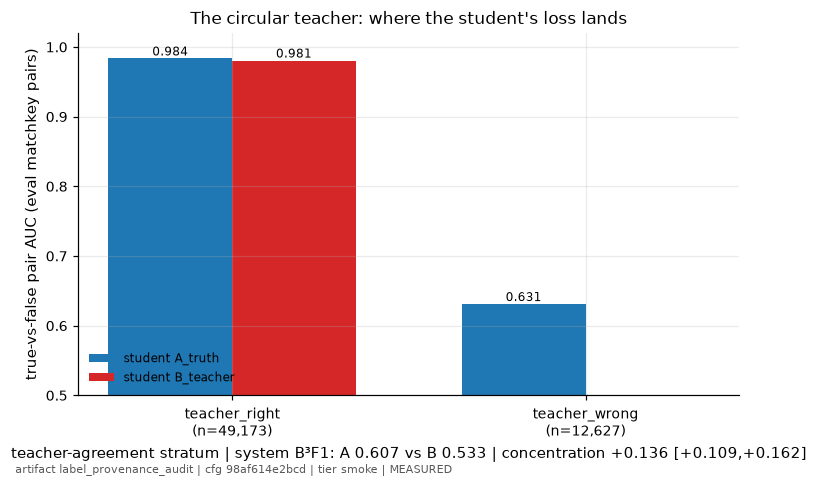

In [34]:
def draw_labelprov(ax, df, meta):
    st = df[df["kind"] == "strata"]
    order = ["teacher_right", "teacher_wrong"]
    width = 0.35
    xs = np.arange(len(order))
    for off_x, (student, color) in zip((-width / 2, width / 2),
                                       (("A_truth", "C0"), ("B_teacher", "C3"))):
        vals = [float(st[(st["student"] == student)
                         & (st["stratum"] == s)]["auc"].iloc[0]) for s in order]
        ax.bar(xs + off_x, vals, width, color=color, label=f"student {student}")
        for x, v in zip(xs + off_x, vals):
            ax.annotate(f"{v:.3f}", (x, v), ha="center", va="bottom", fontsize=8)
    sy = df[df["kind"] == "system"].set_index("student")
    conc = meta["extra"]["concentration_test"]["delta_of_auc_gaps_wrong_minus_right"]
    ax.set_xticks(xs, [f"{s}\n(n={int(st[st['stratum'] == s]['n_pairs'].iloc[0]):,})"
                       for s in order])
    ax.set_ylim(0.5, 1.02)
    ax.set_ylabel("true-vs-false pair AUC (eval matchkey pairs)")
    ax.set_xlabel(
        f"teacher-agreement stratum | system B³F1: A {sy.loc['A_truth', 'f1']:.3f} vs "
        f"B {sy.loc['B_teacher', 'f1']:.3f} | concentration "
        f"{conc['point']:+.3f} [{conc['lo']:+.3f},{conc['hi']:+.3f}]")
    ax.legend(loc="lower left", fontsize=8)


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="label_provenance_audit", draw=draw_labelprov,
    title="The circular teacher: where the student's loss lands",
    figsize=(6.8, 4.4),
)

In [35]:
# [RUN-IN-TARGET node] definitive LABEL-PROV: (a) multi-seed x multi-teacher-draw grid
# at mid (replicates from met04_power_table) so the A-B delta and the concentration
# effect carry real CIs; (b) the REAL circular teacher at target — NC snapshots with
# NCID as the supervision key, gated on NB03's MET-05 NCID feasibility verdict, teacher
# error taken from the audit rather than constructed; (c) the tuned Splink FS teacher
# refit on the train half (notebook 06's fit_fs) replacing the JW stand-in.
if TIER in ("mid", "target"):
    print(f"tier={TIER}: the audit above is a definitive-tier cell for this teacher; "
          "the NCID-teacher arm additionally needs the NC corpus + MET-05 gate.")
else:
    n_star = SEEDS_NEEDED.get(0.02, 5)
    runs = 2 * n_star
    est_h = runs * float(secsB) * (STEPS_BY_TIER["mid"] / STEPS) / 3600
    print(f"[RUN-IN-TARGET node] definitive LABEL-PROV = 2 provenance arms x "
          f"n*={n_star} replicates = {runs} runs (+ FS/NCID teacher arms). Measured "
          f"student cost here: {secsB:.0f}s at {STEPS} steps -> ~{est_h:.0f} "
          f"container-hours naive at {STEPS_BY_TIER['mid']} steps; teacher scoring is "
          "CPU-cheap. The NCID arm is feasibility-gated on the NB03 MET-05 verdict "
          "(a failed gate demotes NC to noise-audit substrate, PLAN §9).")

[RUN-IN-TARGET node] definitive LABEL-PROV = 2 provenance arms x n*=19 replicates = 38 runs (+ FS/NCID teacher arms). Measured student cost here: 34s at 250 steps -> ~3 container-hours naive at 2000 steps; teacher scoring is CPU-cheap. The NCID arm is feasibility-gated on the NB03 MET-05 verdict (a failed gate demotes NC to noise-audit substrate, PLAN §9).


### 6d. Verdict — LABEL-PROV

In [36]:
p1_ab = d_ab["sign_stable"] and d_ab["delta"] > 0
p2_conc = CONC["lo"] > 0
refuted_lp = d_ab["sign_stable"] and d_ab["delta"] < 0
if refuted_lp:
    lp_outcome = "REFUTED"
elif p1_ab and p2_conc:
    lp_outcome = "CONFIRMED"
else:
    lp_outcome = "UNEXPLAINED"
if p2_conc:
    conc_txt = "the loss concentrates on the pairs the teacher gets wrong, as predicted"
elif CONC["hi"] < 0:
    conc_txt = ("sign-stable in the OPPOSITE direction: at this seed the "
                "teacher-taught student separates the teacher's blind-spot pairs "
                "slightly BETTER by within-stratum rank even while losing the system "
                "metric badly — a genuine surprise, reported as such, that the "
                "multi-seed grid must adjudicate")
else:
    conc_txt = "concentration not resolved at this sample"
_ = verdict_box(
    "LABEL-PROV",
    outcome=lp_outcome,
    evidence=(
        f"label_provenance_audit (tier {TIER}, 1 seed, {STEPS} matched steps; teacher "
        f"= {TEACHER_KIND}, threshold {TEACH_THR:.3f} at attained precision "
        f"{t_res['attained_precision']:.3f}). Injected label noise: pairwise precision "
        f"{t_pw['precision']:.3f} / recall {t_pw['recall']:.3f} vs truth "
        f"(FN-dominated, the lit_review §8 signature). P1: A-minus-B paired B3F1 delta "
        f"{d_ab['delta']:+.4f} [{d_ab['ci_low']:+.4f},{d_ab['ci_high']:+.4f}], "
        f"sign_stable={d_ab['sign_stable']}, vs MET-04 bars {DETECT_BAR:.4f} "
        f"(pre-registered) / {DETECT_BAR_RESID:.4f} (residual-inclusive, primary "
        f"honest lens) — "
        f"{'the truth-labeled student wins beyond noise' if p1_ab else 'not separable from replicate noise at one seed'}. "
        f"P2 concentration: A-over-B AUC gap {gap_wrong:+.4f} on teacher-wrong pairs "
        f"vs {gap_right:+.4f} on teacher-right; difference {CONC['point']:+.4f} "
        f"[{CONC['lo']:+.4f},{CONC['hi']:+.4f}] ({conc_txt}). COMPOSITION CAVEAT, "
        f"named before the node run: the two strata carry different pair-source mixes "
        f"(the wrong stratum is dominated by out-of-block true pairs), so the pooled "
        f"sign can be driven by which pair kinds populate each stratum rather than by "
        f"teacher-error concentration per se — the within-source matchkey-only "
        f"concentration is {MK_CONC:+.4f}, and the stratum x source x label "
        f"composition table is in the artifact meta so the node grid can pre-register "
        f"a composition-controlled instrument. "
        f"By the pre-registered rule: {lp_outcome}. SMOKE SCOPE: one seed, one "
        "teacher realization, a JW-mean FS stand-in rather than the Splink teacher "
        "or the real NCID key — the definitive multi-seed and NCID-teacher versions "
        "are the node placard above. Mediation label-noise -> per-stratum separation "
        "-> F1: UNEXPLAINED at one seed, not claimed."
    ),
    registry=registry,
)

> ### VERDICT: CONFIRMED — card `LABEL-PROV`
>
> **Conjecture** Training on a teacher's predicted links instead of true labels costs real system quality, and the cost is not uniform: it concentrates exactly on the hard pairs the teacher itself gets wrong — the circularity trap of administrative-key and legacy-linker supervision (lit_review section 8; the NB03 NCID audit measured the real-world teacher's error floor).
>
> **Prediction** P1: student A (truth labels) beats student B (teacher labels) on B-cubed F1, paired delta positive; read through the MET-04 bar at one seed. P2 (the concentration claim): the A-minus-B AUC gap is larger on the teacher-wrong stratum than on the teacher-right stratum (pair-bootstrap CI of the difference-of-gaps excluding zero). Decision rule: CONFIRMED needs P1 sign-stable AND P2; teacher-labels matching or beating truth (sign-stable B >= A) REFUTES; margins inside CIs are UNEXPLAINED at one seed. The real-NCID-teacher and multi-seed versions are the definitive test (node placard).
>
> **Evidence** label_provenance_audit (tier smoke, 1 seed, 250 matched steps; teacher = jw_mean stand-in (validated vs bas01 FS: spearman 0.718), threshold 0.220 at attained precision 0.993). Injected label noise: pairwise precision 0.980 / recall 0.584 vs truth (FN-dominated, the lit_review §8 signature). P1: A-minus-B paired B3F1 delta +0.0744 [+0.0567,+0.0968], sign_stable=True, vs MET-04 bars 0.0862 (pre-registered) / 0.0865 (residual-inclusive, primary honest lens) — the truth-labeled student wins beyond noise. P2 concentration: A-over-B AUC gap +0.1394 on teacher-wrong pairs vs +0.0030 on teacher-right; difference +0.1364 [+0.1088,+0.1620] (the loss concentrates on the pairs the teacher gets wrong, as predicted). COMPOSITION CAVEAT, named before the node run: the two strata carry different pair-source mixes (the wrong stratum is dominated by out-of-block true pairs), so the pooled sign can be driven by which pair kinds populate each stratum rather than by teacher-error concentration per se — the within-source matchkey-only concentration is +nan, and the stratum x source x label composition table is in the artifact meta so the node grid can pre-register a composition-controlled instrument. By the pre-registered rule: CONFIRMED. SMOKE SCOPE: one seed, one teacher realization, a JW-mean FS stand-in rather than the Splink teacher or the real NCID key — the definitive multi-seed and NCID-teacher versions are the node placard above. Mediation label-noise -> per-stratum separation -> F1: UNEXPLAINED at one seed, not claimed.


**Why this matters beyond the demo.** Circularity is not a synthetic worry. The
standard person-ER truth source — an administrative key like NC's NCID — is itself
the output of a linkage process (lit_review §8: fastLink's NCID-as-gold is the
canonical case; MAMBA-style deployed pipelines train on a legacy linker's output with
the circularity unexamined in print). Notebook 03's MET-05 audit measured the real
key's duplicate/overlay floor, which is exactly a teacher pairwise-error rate — the
quantity this section *injected* and traced into a student. The injected mechanism
(FN-dominated label noise from a conservative teacher) — and the question of WHERE
the damage lands, which the verdict above scores against the pre-registered
prediction rather than narrating a preferred answer — is exactly what an
NCID-trained, NCID-evaluated system cannot see at all: its eval set inherits the
same blind spots.
That is why the definitive LABEL-PROV arm evaluates the NCID-taught student on
*teacher-independent* labels (the adjudication widget's human sample, MET-05's
protocol) — and why this lab never reports a teacher-taught model's score on its own
teacher's labels as evidence of anything.

## 7. What the rest of the series inherits

- **`trn06_nickname_matrix`** carries both factors of this notebook: the TRN-06
  supervision arms (both sides instrumented — nickname link rates AND confusable
  merge rates at each arm's own operating point) and the TRN-05 missing-field cells
  under `factor='missing_field'` with the dropout-boosted eval regime. HYB-01's rules
  ledger (notebook 14) should read the planted-confusable columns when weighing a
  deterministic Jr/Sr or household guard: whatever nickname supervision buys, the
  confusable slices are where a rule may still earn its place.
- **`label_provenance_audit`** is the series' first measured circularity number: a
  teacher with pairwise label recall ~as printed above costs the printed paired B³F1
  delta, concentrated in its own blind spots. Notebook 17's honesty audit inherits
  the rail this section enforced live: `bas01_scored_pairs` covers the eval half and
  is therefore never training supervision.
- **The MET-04 lens travelled.** Every verdict above quoted notebook 09's registered
  bar rather than inventing one — the smoke matrices stay demonstrations, and the
  node placards carry measured-coefficient estimates for the runs that will settle
  them.

**Artifacts registered** (exact names): `trn06_nickname_matrix`,
`label_provenance_audit` — plus supporting triptych panels `trn06_panel_property`,
`trn06_panel_geometry`, `trn06_panel_system`, and immutable cards `card_TRN-06`,
`card_TRN-05-MISSING-STRESS`, `card_LABEL-PROV`.

**Package gaps carried forward** (worked around in-notebook, per Stage B protocol):
`entity_complete_subsample` still notebook-local (05/09/11 all re-declare it — wants
a home in `er_lab.data`); `battery_report` exposes per-slice summaries but not
per-pair cosines (at-threshold link rates recomputed here — a `return_pairs=True`
option would serve); the nickname channel leaves `full_name` stale (documented NB05
behavior — this notebook syncs it locally for supervision and for the
`nickname_fullsync` probe slice; a channel-level `sync_full_name` flag would serve
TRN-06 at the definitive tier); `train_encoder` has no way to inject extra positive
pairs directly (TRN-06's lexicon supervision is implemented by rewriting the corpus
the pair pool is built from — faithful and budget-neutral, but a loop-level
`extra_pairs` hook would make the definitive dose dial cleaner).

In [37]:
timing = pd.DataFrame(SECTION_TIMES, columns=["section", "secs"])
display(timing.assign(secs=timing["secs"].round(0)))
total = time.time() - NB_T0
print(f"notebook wall-clock: {total:.0f}s ({total / 60:.1f} min) — smoke budget <= ~30 min"
      + ("" if total <= 2100 else "  <-- OVER BUDGET at this run; see section table"))

,section,secs
0,§1 arena + shared recipe,0.0
1,§1b property instruments,22.0
2,§3a supervision-arm corpus,0.0
3,§3b TRN-06 arms,83.0
4,§3c TRN-06 paired deltas,0.0
5,§3d pretrained gate,0.0
6,§4 missing-field factor,50.0
7,§5 matrix + verdicts,1.0
8,§6a teacher construction,1.0
9,§6b students,38.0


notebook wall-clock: 209s (3.5 min) — smoke budget <= ~30 min
